In [ ]:

import sys
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import numpy as np
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker, HPacker, DrawingArea
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe
import seaborn as sns
import random
import pickle

from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    auc
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
DATA_DIR = PROJECT_DIR / "cached_data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
RESULT_DIR = PROJECT_DIR / "testing_results"

sys.path.append(str(PROJECT_DIR))

import scripts.train_tf_to_dna_model as tf_dna_train
import models.tf_to_tg as tf_to_tg_module
import plotting_utils
import stat_utils
import utils
import warnings
import config

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

font_path = PROJECT_DIR / "fonts" / "Arial.ttf"

fm.fontManager.addfont(font_path)
arial_font = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [arial_font, "Helvetica", "Liberation Sans", "DejaVu Sans"]

logging.info(f"Using font: {arial_font}")

rng = np.random.default_rng()

INFO - Using font: Arial


In [2]:
OWN_MODEL_METHOD = "TF-TG Model (own test set)"
CROSS_MODEL_METHOD = "TF-TG Model (cross-trained)"

TFTG_MODEL_METHODS = [
    OWN_MODEL_METHOD,
    CROSS_MODEL_METHOD,
]

method_display_name_map = {
    OWN_MODEL_METHOD: "TF-TG Own",
    CROSS_MODEL_METHOD: "TF-TG Cross",
}

## Formatting Dictionaries

In [3]:
sample_order = [
    "E7.5_rep1",
    "E8.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
    "hepatocytes_1",
    "hepatocytes_3",
]

sample_rename_map = {
    "E7.5_rep1": "mESC-1",
    "E8.5_rep1": "mESC-2",
    "buffer_1": "Macrophage-1",
    "buffer_2": "Macrophage-2",
    "sample_1": "K562",
    "hepatocytes_1": "Hepatocytes-1",
    "hepatocytes_3": "Hepatocytes-2",

    OWN_MODEL_METHOD: "MTGRN-STM", #"TF-TG Model\n(Own)",
    CROSS_MODEL_METHOD: "MTGRN-CTM", #"TF-TG Model\n(Cross)",
}

sample_color_map = {
    "E7.5_rep1": "#4195df",
    "E8.5_rep1": "#86C7E7",
    "buffer_1": "#EF767A",
    "buffer_2": "#F9C60D",
    "sample_1": "#EF9CFA",
    "hepatocytes_1": "#82EC32",
    "hepatocytes_3": "#F98637",
}

method_color_dict = {
    OWN_MODEL_METHOD: "#4195df",
    CROSS_MODEL_METHOD: "#86C7E7",
    "LINGER": "#EF767A",
    "CellOracle": "#F9C60D",
    "Pando": "#EF9CFA",
    "SCENIC+": "#82EC32",
    "FigR": "#FDA7BB",
    "GRaNIE": "#F98637",
}

# method_color_dict = {
#     OWN_MODEL_METHOD: "#1f78b4",
#     CROSS_MODEL_METHOD: "#a6cee3",
#     "LINGER": "#fb9a99",
#     "CellOracle": "#fdbf6f",
#     "Pando": "#cab2d6",
#     "SCENIC+": "#b2df8a",
#     "FigR": "#ffff99",
# }

org_dict = {
    "E7.5_rep1": ("mouse", "mESC"),
    "E8.5_rep1": ("mouse", "mESC"),
    "buffer_1": ("human", "Macrophage"),
    "buffer_2": ("human", "Macrophage"),
    "hepatocytes_1": ("mouse", "mouse_hepatocytes"),
    "hepatocytes_3": ("mouse", "mouse_hepatocytes"),
    "sample_1": ("human", "K562"),
    "WT_D13_rep1": ("human", "iPSC")
}

models_to_plot = [
    "E7.5_rep1",
    "E8.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
    "hepatocytes_1",
    "hepatocytes_3",
]

## Paths

In [4]:
tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

score_label_save_dir = RESULT_DIR / "model_generalizability" / "labeled_grns"
score_label_save_dir.mkdir(parents=True, exist_ok=True)

method_comparison_boxplot_dir = PROJECT_DIR / "plots" / "model_vs_other_method_boxplots"
method_comparison_boxplot_dir.mkdir(exist_ok=True, parents=True)

lift_boxplot_dir = method_comparison_boxplot_dir / "lift_boxplots"
lift_boxplot_dir.mkdir(parents=True, exist_ok=True)

model_vs_other_method_curve_dir = PROJECT_DIR / "plots" / "model_vs_other_method_auroc_auprc_curves"
model_vs_other_method_curve_dir.mkdir(exist_ok=True, parents=True)

generalizability_plot_dir = PROJECT_DIR / "plots" / "generalizability"
generalizability_plot_dir.mkdir(parents=True, exist_ok=True)

feature_ablation_plot_dir = PROJECT_DIR / "plots" / "feature_ablation"
feature_ablation_plot_dir.mkdir(parents=True, exist_ok=True)

tf_dna_plots = PROJECT_DIR / "plots" / "tf_dna_binding_plots"
tf_dna_plots.mkdir(parents=True, exist_ok=True)

roc_plot_dir = PROJECT_DIR / "plots" / "roc_curves"
roc_plot_dir.mkdir(parents=True, exist_ok=True)

auprc_plot_dir = PROJECT_DIR / "plots" / "auprc_plots"
auprc_plot_dir.mkdir(parents=True, exist_ok=True)

rank_plot_dir = PROJECT_DIR / "plots" / "rank_plots"
rank_plot_dir.mkdir(parents=True, exist_ok=True)

rank_bar_plot_dir = rank_plot_dir / f"rank_barplots"
rank_lollipop_plot_dir = rank_plot_dir / f"rank_lollipop_plots"
rank_heatmap_plot_dir = rank_plot_dir / f"rank_heatmaps"
rank_boxplot_plot_dir = rank_plot_dir / f"rank_boxplots"

rank_bar_plot_dir.mkdir(parents=True, exist_ok=True)
rank_lollipop_plot_dir.mkdir(parents=True, exist_ok=True)
rank_heatmap_plot_dir.mkdir(parents=True, exist_ok=True)
rank_boxplot_plot_dir.mkdir(parents=True, exist_ok=True)

grn_sizes_by_method_dir = PROJECT_DIR / "plots" / "grn_sizes_by_method"
grn_sizes_by_method_dir.mkdir(parents=True, exist_ok=True)

# File path for the full metrics DataFrame CSV
full_metric_df_path = RESULT_DIR / "full_method_comparison_metrics.csv"

# Plot showing how the model performs on its own test set, on other samples, on other cell types, and on other species
performance_across_evaluation_sets_plot_path = generalizability_plot_dir / "mean_performance_across_evaluation_sets.png"

# One subplot for each sample
auroc_models_vs_test_set_individual_plot_path = roc_plot_dir / "models_vs_own_test_set_auroc.png"

# Combined plot for all samples (one curve per sample)
auroc_models_vs_test_set_all_samples_plot_path = roc_plot_dir / "models_vs_own_test_set_auroc_combined.png"
auprc_models_vs_test_set_all_samples_plot_path = auprc_plot_dir / "models_vs_own_test_set_auprc_combined.png"
auprc_lift_models_vs_test_set_all_samples_plot_path = auprc_plot_dir / "models_vs_own_test_set_auprc_lift_combined.png"

# PRC curves for our model vs other methods, one figure per sample
model_vs_other_method_prc_curve_fig_dir = model_vs_other_method_curve_dir / "prc_curve_figs"
model_vs_other_method_prc_curve_fig_dir.mkdir(parents=True, exist_ok=True)

# ROC curves for our model vs other methods, one figure per sample
model_vs_other_method_roc_curve_fig_dir = model_vs_other_method_curve_dir / "roc_curve_figs"
model_vs_other_method_roc_curve_fig_dir.mkdir(parents=True, exist_ok=True)


## Load the latest model checkpoints for each sample

In [5]:
tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3675131" / "epoch_11_best_model.ckpt",
        # "E7.5_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E7.5_rep1"),
        "E7.5_rep2": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E7.5_rep2"),
        "E8.5_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E8.5_rep1", training_number="3691937"),
        "E8.5_rep2": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E8.5_rep2", training_number="3691937"),
    },
    "iPSC": {
        "WT_D13_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_1", training_number="3685893"),
        "buffer_2": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_2", training_number="3713132"),
        "buffer_3": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_3"),
        "buffer_4": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_4"),
    },
    "K562": {
        "sample_1": utils.find_latest_checkpoint(CHKPT_DIR, "K562", "sample_1", training_number="3692409"),
    },
    "mouse_liver": {
        "liver_1": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_liver", "liver_1"),
        "liver_3": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_liver", "liver_3")
    },
    "mouse_hepatocytes": {
        "hepatocytes_1": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_hepatocytes", "hepatocytes_1"),
        "hepatocytes_3": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_hepatocytes", "hepatocytes_3"),
    }
}

INFO - Latest checkpoint for mESC E7.5_rep2: Job 3696113 Epoch 76
INFO - Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 42
WARNING - No checkpoint directories found for mESC E8.5_rep2 in /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/mESC/E8.5_rep2
INFO - Latest checkpoint for iPSC WT_D13_rep1: Job 3709598 Epoch 52
INFO - Latest checkpoint for Macrophage buffer_1: Job 3685893 Epoch 152
INFO - Latest checkpoint for Macrophage buffer_2: Job 3713132 Epoch 46
INFO - Latest checkpoint for Macrophage buffer_3: Job 3704579 Epoch 52
INFO - Latest checkpoint for Macrophage buffer_4: Job 3696147 Epoch 209
INFO - Latest checkpoint for K562 sample_1: Job 3692409 Epoch 63
INFO - Latest checkpoint for mouse_liver liver_1: Job 3708415 Epoch 42
INFO - Latest checkpoint for mouse_liver liver_3: Job 3708657 Epoch 48
INFO - Latest checkpoint for mouse_hepatocytes hepatocytes_1: Job 3709466 Epoch 33
INFO - Latest checkpoint for mouse_hepatocytes hepatoc

## Functions

In [ ]:
def run_prediction_vs_test_set(
    tf_tg_model_checkpoints: dict,
    model_cell_type: str,
    model_training_sample: str,
    test_set_cell_type: str,
    evaluation_sample: str,
    dataset_split_type: str = "test",
    subset_size: int | None = None,
    show_progress_bar: bool = True,
    compile_model: bool = True,
    ) -> dict | None:
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][model_training_sample]
    tf_dna_model_chkpt = config.tf_dna_model_checkpoints[model_cell_type]
    
    if tf_tg_model_chkpt is None:
        logging.warning(f"Skipping evaluation for {model_cell_type} {model_training_sample} → {test_set_cell_type} {evaluation_sample} due to missing TF-TG checkpoint")
        return None

    cell_type_cache_dir = DATA_DIR / f"{test_set_cell_type}_cache"

    # print(f"Loading cached dataset with subset size: {subset_size}")
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
        sample_name=evaluation_sample,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=dataset_split_type,
        subset_size=subset_size
        )
    
    tf_tg_model = utils.load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor,
        compile_model=compile_model
        )

    # print("Moving model to device")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = tf_tg_model.model
    model = model.to(device)

    criterion = torch.nn.BCEWithLogitsLoss()
    score_threshold = 0.5
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model.eval()

    total_loss = 0.0
    n_edges = 0

    all_scores = []
    all_labels = []
    plot_data = {}

    # print(f"Evaluating on {dataset_split_type} set")
    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100, disable=not show_progress_bar):
            
            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            labels = batch["label"]
            cell_mask = batch["cell_mask"]
            E, C = cell_mask.shape

            edge_logits, _ = model.forward(
                tf_embedding=batch["tf_embedding"],
                tf_mask=batch["tf_mask"],
                peak_sequences=batch["peak_sequences"],
                peak_accessibility=batch["peak_accessibility"],
                peak_distance=batch["peak_distance"],
                tf_expression=batch["tf_expression"],
                tg_expression=batch["tg_expression"],
                peak_mask=batch.get("peak_mask", None),
                cell_mask=cell_mask,
                pooling_mode=pooling_mode,
                pooling_temperature=pooling_temperature,
            )

            loss = criterion(edge_logits, labels)

            total_loss += loss.item() * E
            n_edges += E

            scores = torch.sigmoid(edge_logits)

            all_scores.append(scores.detach().cpu().numpy().ravel())
            all_labels.append(labels.detach().cpu().numpy().ravel())

    all_scores_flat = np.concatenate(all_scores)
    all_labels_flat = np.concatenate(all_labels)

    metrics = stat_utils.compute_binary_classification_metrics(
        labels=all_labels_flat,
        scores=all_scores_flat,
        score_threshold=score_threshold,
        random_state=42,
    )

    metrics["Model"] = model_training_sample
    metrics["Test Set"] = evaluation_sample

    metric_df = pd.DataFrame([metrics])

    col_order = [
        "Model", 
        "Test Set", 
        "auroc", 
        "auprc", 
        "accuracy", 
        "precision", 
        "early_precision", 
        "recall", 
        "f1", 
        "rand_auroc", 
        "rand_auprc",
        "n_edges",
        "n_pos",
        "n_neg",
        "score_threshold"
        ]

    metric_df = metric_df[col_order]
    
    title = f"{model_cell_type} {model_training_sample} Model → {test_set_cell_type} {evaluation_sample} Test Set"
    
    plot_data = [all_labels_flat, all_scores_flat]
    
    return {
        "metric_df": metric_df,
        "plot_data": plot_data,
        "title": title
    }


def load_tf_dna_training_data(
    cell_type: str,
    batch_size: int = 64,
):
    training_cache_dir = DATA_DIR / f"{cell_type}_cache"
    tf_dna_input_cache_dir = training_cache_dir / "tf_dna_training_cache"
    
    # Shared cache files for both TF-to-TG and TF-to-DNA training
    tf_embedding_cache_path = training_cache_dir / "tf_embeddings.pt"
    tf_mask_cache_path = training_cache_dir / "tf_masks.pt"
    
    # TF-DNA training specific cache files
    tf_dna_edge_tf_idx_cache_path = tf_dna_input_cache_dir / "edge_tf_idx.pt"
    tf_dna_edge_peak_idx_cache_path = tf_dna_input_cache_dir / "edge_peak_idx.pt"
    tf_dna_edge_labels_cache_path = tf_dna_input_cache_dir / "edge_labels.pt"
    tf_dna_tf_lengths_cache_path = tf_dna_input_cache_dir / "tf_lengths.pt"
    tf_dna_peak_onehot_cache_path = tf_dna_input_cache_dir / "peak_onehot_array.pt"
    
    tf_dna_train_idx_cache_path = tf_dna_input_cache_dir / "train_idx.pt"
    tf_dna_val_idx_cache_path = tf_dna_input_cache_dir / "val_idx.pt"
    tf_dna_test_idx_cache_path = tf_dna_input_cache_dir / "test_idx.pt"
    
    # Name to ID dictionaries
    tf_name_to_idx_cache_path = training_cache_dir / "tf_name_to_idx.csv"
    tf_dna_peak_id_to_idx_cache_path = tf_dna_input_cache_dir / "peak_id_to_idx.csv"

    # Load cached data
    edge_tf_idx_tensor: torch.Tensor = torch.load(tf_dna_edge_tf_idx_cache_path, weights_only=True)
    edge_peak_idx_tensor: torch.Tensor = torch.load(tf_dna_edge_peak_idx_cache_path, weights_only=True)
    edge_labels_tensor: torch.Tensor = torch.load(tf_dna_edge_labels_cache_path, weights_only=True)
    tf_embeddings_tensor: torch.Tensor = torch.load(tf_embedding_cache_path, weights_only=True)
    tf_mask_tensor: torch.Tensor = torch.load(tf_mask_cache_path, weights_only=True)
    peak_tensor: torch.Tensor = torch.load(tf_dna_peak_onehot_cache_path, weights_only=True)
    
    tf_name_to_idx_df = pd.read_csv(tf_name_to_idx_cache_path)
    peak_id_to_idx_df = pd.read_csv(tf_dna_peak_id_to_idx_cache_path)
    
    # Load train/val/test splits
    train_idx: torch.Tensor = torch.load(tf_dna_train_idx_cache_path, weights_only=True)
    val_idx: torch.Tensor = torch.load(tf_dna_val_idx_cache_path, weights_only=True)
    test_idx: torch.Tensor = torch.load(tf_dna_test_idx_cache_path, weights_only=True)

    if peak_tensor.dtype == torch.uint8:
        peak_tensor = peak_tensor.float()

    edge_dataset = tf_dna_train.TFPeakEdgeDataset(
        edge_tf_idx=edge_tf_idx_tensor,
        edge_peak_idx=edge_peak_idx_tensor,
        edge_labels=edge_labels_tensor,
        peak_tensor=peak_tensor,
    )
    
    train_dataset = Subset(edge_dataset, train_idx.tolist())
    val_dataset = Subset(edge_dataset, val_idx.tolist())
    test_dataset = Subset(edge_dataset, test_idx.tolist())

    # Create dataloaders for each split
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=8,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )
    
    return {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "tf_embeddings_tensor": tf_embeddings_tensor,
        "tf_mask_tensor": tf_mask_tensor,
        "peak_tensor": peak_tensor,
        "edge_dataset": edge_dataset,
        "tf_name_to_idx_df": tf_name_to_idx_df,
        "peak_name_to_idx_df": peak_id_to_idx_df,
    }

def generate_model_predictions(
    model, 
    data_loader, 
    device, 
    tf_idx_to_name, 
    tg_idx_to_name,
    compile_model=False,
    ):
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model = model.to(device)
    model.eval()
    
    if compile_model and device.type == "cuda":
        model = torch.compile(model, mode="reduce-overhead")

    tf_indices_list = []
    tg_indices_list = []
    all_scores = []

    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
            tf_indices = batch["tf_idx"].detach().cpu().numpy().ravel()
            tg_indices = batch["tg_idx"].detach().cpu().numpy().ravel()

            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                edge_logits, _ = model(
                    tf_embedding=batch["tf_embedding"],
                    tf_mask=batch["tf_mask"],
                    peak_sequences=batch["peak_sequences"],
                    peak_accessibility=batch["peak_accessibility"],
                    peak_distance=batch["peak_distance"],
                    tf_expression=batch["tf_expression"],
                    tg_expression=batch["tg_expression"],
                    peak_mask=batch.get("peak_mask", None),
                    cell_mask=batch["cell_mask"],
                    pooling_mode=pooling_mode,
                    pooling_temperature=pooling_temperature,
                )

            scores = torch.sigmoid(edge_logits.float())

            tf_indices_list.append(tf_indices)
            tg_indices_list.append(tg_indices)
            all_scores.append(scores.detach().cpu().numpy().ravel())

    all_tf_indices_flat = np.concatenate(tf_indices_list)
    all_tg_indices_flat = np.concatenate(tg_indices_list)
    all_scores_flat = np.concatenate(all_scores)

    tf_names = [tf_idx_to_name[int(idx)].upper() for idx in all_tf_indices_flat]
    tg_names = [tg_idx_to_name[int(idx)].upper() for idx in all_tg_indices_flat]

    prediction_df = pd.DataFrame({
        "Source": tf_names,
        "Target": tg_names,
        "Score": all_scores_flat,
    })

    prediction_df = (
        prediction_df.groupby(["Source", "Target"], as_index=False)["Score"]
        .median()
    )

    return prediction_df

def create_tf_tg_index_to_name_mappings(metadata):
    tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
    tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}
    return tf_idx_to_name, tg_idx_to_name

def create_tf_tg_label_df(tftg_inputs_test):
    # Create the TF-TG label DataFrame
    tftg_inputs_test.keys()
    test_tf_input = tftg_inputs_test["tf_name"]
    test_tg_input = tftg_inputs_test["tg_name"]
    test_labels = tftg_inputs_test["label"]

    # create TF-TG label DataFrame
    tf_tg_label_df = pd.DataFrame({
        "Source": test_tf_input,
        "Target": test_tg_input,
        "Label": test_labels,
    })

    tf_tg_label_df = tf_tg_label_df.drop_duplicates(["Source", "Target"])

    gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1] 
    gt_tfs = set(gt_df["Source"].str.upper().unique()) 
    gt_targets = set(gt_df["Target"].str.upper().unique()) 
    gt_pairs = set(gt_df["Source"].str.upper() + "\t" + gt_df["Target"].str.upper())
    
    return tf_tg_label_df, gt_pairs, gt_tfs, gt_targets

def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    sample_rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in sample_rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=sample_rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()
    
    df["Score"] = np.abs(df["Score"])

    return df

def precision_at_k(y_true, y_score, k=1_000):
    """Calculate precision among the k highest-scoring predictions."""
    y_true = np.asarray(y_true, dtype=int).ravel()
    y_score = np.asarray(y_score, dtype=float).ravel()

    if len(y_true) != len(y_score):
        raise ValueError(
            f"y_true and y_score have different lengths: "
            f"{len(y_true)} and {len(y_score)}"
        )

    if len(y_true) == 0:
        return np.nan

    if k <= 0:
        raise ValueError("k must be greater than zero.")

    effective_k = min(k, len(y_true))

    top_k_indices = np.argsort(-y_score, kind="stable")[:effective_k]
    top_k_labels = y_true[top_k_indices]

    return float(top_k_labels.mean())

def compute_metrics(method_name: str, sample_name: str, df: pd.DataFrame, gt_pairs: set, score_threshold: float):
    if len(df) == 0:
        labels = np.array([], dtype=int)
        scores = np.array([], dtype=float)
    else:
        labels = np.asarray(
            [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
        ).astype(int).ravel()
        scores = np.asarray(df["Score"].tolist()).astype(float).ravel()

    n_edges = len(labels)
    has_both_classes = n_edges > 0 and len(np.unique(labels)) >= 2

    if n_edges == 0:
        early_precision = accuracy = precision = recall = f1 = np.nan
        auroc = random_auroc = np.nan
    else:
        preds = (scores >= score_threshold).astype(int)

        early_precision = precision_at_k(labels, scores, k=10_000)
        accuracy = accuracy_score(labels, preds)
        precision = precision_score(labels, preds, zero_division=0)
        recall = recall_score(labels, preds, zero_division=0)
        f1 = f1_score(labels, preds, zero_division=0)

        if has_both_classes:
            auroc = roc_auc_score(labels, scores)
            random_auroc = roc_auc_score(labels, np.random.rand(n_edges))
        else:
            auroc = np.nan
            random_auroc = np.nan

    return pd.DataFrame([{
        "method_name": method_name,
        "sample_name": sample_name,
        "auroc": auroc,
        "rand_auroc": random_auroc,
        "early_precision": early_precision,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_edges": n_edges,
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "score_threshold": score_threshold,
    }])

def load_auprc_grns_all_methods(sample_list=None):
    auprc_all_method_dfs = {}

    if sample_list is not None:
        sample_list = set(sample_list)

    method_name_from_safe = {
        "celloracle": "CellOracle",
        "scenic": "SCENIC+",
        "linger": "LINGER",
        "pando": "Pando",
        "figr": "FigR",
        "tf-tg model (own test set)": OWN_MODEL_METHOD,
        "tf-tg model (cross-trained)": CROSS_MODEL_METHOD,
    }

    for cell_type_dir in (RESULT_DIR / "labeled_auprc_grns").iterdir():
        if not cell_type_dir.is_dir():
            continue

        for sample_dir in cell_type_dir.iterdir():
            if not sample_dir.is_dir():
                continue

            if sample_list is not None and sample_dir.name not in sample_list:
                continue

            # Create nested dict before assigning methods
            auprc_all_method_dfs.setdefault(sample_dir.name, {})

            for method_file in sample_dir.glob("*.tsv"):
                method_name_safe = method_file.stem

                if method_name_safe not in method_name_from_safe:
                    logging.warning(
                        f"Unrecognized method name: {method_name_safe}. Using as-is."
                    )

                method_name = method_name_from_safe.get(method_name_safe, method_name_safe)

                auprc_df = pd.read_csv(method_file, sep="\t")
                auprc_all_method_dfs[sample_dir.name][method_name] = auprc_df

    return auprc_all_method_dfs

def load_generalizability_df(model_sample_name, test_set_sample_name, sample_size=10000):
    score_label_save_dir = RESULT_DIR / "model_generalizability" / "labeled_grns"
    
    score_label_file = (
        score_label_save_dir
        / f"{model_sample_name}_model_vs_{test_set_sample_name}_grn_{sample_size}.csv"
    )
    
    if not score_label_file.exists():
        logging.warning(f"Score-label file not found for {model_sample_name} vs {test_set_sample_name}. Skipping.")
        return None
    
    score_label_df = pd.read_csv(score_label_file)

    return score_label_df

def interpolate_precision_at_recall(source_rec, source_prec, target_rec):
    source_rec = np.asarray(source_rec, dtype=float)
    source_prec = np.asarray(source_prec, dtype=float)
    target_rec = np.asarray(target_rec, dtype=float)

    valid = np.isfinite(source_rec) & np.isfinite(source_prec)
    source_rec = source_rec[valid]
    source_prec = source_prec[valid]

    # np.interp expects ascending x values
    order = np.argsort(source_rec)
    source_rec = source_rec[order]
    source_prec = source_prec[order]

    # Collapse duplicate recall values
    interp_df = (
        pd.DataFrame({
            "recall": source_rec,
            "precision": source_prec,
        })
        .groupby("recall", as_index=False)["precision"]
        .mean()
    )

    return np.interp(
        target_rec,
        interp_df["recall"].to_numpy(),
        interp_df["precision"].to_numpy(),
    )

---

## Run model vs test set

In [12]:
# all_comparison_df_list = []

# evaluations = [
#     ("mESC", "E7.5_rep1", "mESC", "E7.5_rep1"),
#     # ("mESC", "E8.5_rep1", "mESC", "E8.5_rep1"),
    
#     # ("mouse_hepatocytes", "hepatocytes_1", "mouse_hepatocytes", "hepatocytes_1"),
#     # ("mouse_hepatocytes", "hepatocytes_3", "mouse_hepatocytes", "hepatocytes_3"),
    
#     # ("Macrophage", "buffer_1", "Macrophage", "buffer_1"),
#     # ("Macrophage", "buffer_2", "Macrophage", "buffer_2"),
    
#     # ("K562", "sample_1", "K562", "sample_1")

# ]

# all_plot_data = {}

# subset_size = 10_000
# # for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in tqdm(evaluations, desc="Evaluating all model vs test set combinations", ncols=100):
# for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in evaluations:
#     logging.info(f"Evaluating {model_cell_type} {model_training_sample} Model → {test_set_cell_type} {evaluation_sample} Test Set")

#     dataset_split_type = "test"
        
#     comparison_result = run_prediction_vs_test_set(
#         tf_tg_model_checkpoints=tf_tg_model_checkpoints,
#         model_cell_type=model_cell_type,
#         model_training_sample=model_training_sample,
#         test_set_cell_type=test_set_cell_type,
#         evaluation_sample=evaluation_sample,
#         dataset_split_type=dataset_split_type,
#         subset_size=subset_size,
#         show_progress_bar=True,
#         compile_model=True
#     )
        
#     metric_df = comparison_result["metric_df"]
#     plot_data = comparison_result["plot_data"]
    
#     all_labels_flat = plot_data[0]
#     all_scores_flat = plot_data[1]
    
#     title = comparison_result["title"]
    
#     all_plot_data[title] = (all_labels_flat, all_scores_flat)
    
#     all_comparison_df_list.append(metric_df)
    
# full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)

# display(full_comparison_df.T)

In [13]:
# for title in all_plot_data.keys():
#     all_labels_flat = all_plot_data[title][0]
#     all_scores_flat = all_plot_data[title][1]

#     histogram_fig = plotting_utils.plot_score_histograms(
#         labels=all_labels_flat,
#         scores=all_scores_flat,
#         n_bins=50,
#         y_log=False,
#         panel_kind="kde",
#         density=False,
#         title = title
#     )
#     histogram_fig.show()
    
#     model_sample, test_set_sample = title.split(" → ")
#     model_sample = model_sample.split("Model")[0].split()[1].strip()
#     test_set_sample = test_set_sample.split("Test Set")[0].split()[1].strip()
#     title = f"{model_sample} Model\n{test_set_sample} Test Set"

# auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
#     labels=all_labels_flat,
#     scores=all_scores_flat,
#     title = title,
#     plot_type = "roc"
# )
# auroc_auprc_fig.show()

---

## Generalizability

### Load all generalizability comparison metrics

In [7]:
all_comparison_dfs = []
individual_comparison_dir = RESULT_DIR / "model_generalizability" / "comparison_metric_files"
for comparison_file in individual_comparison_dir.glob("*10000.csv"):
    comparison_df = pd.read_csv(comparison_file)
    all_comparison_dfs.append(comparison_df)

num_comparisons = len(all_comparison_dfs)
print(f"Loaded {num_comparisons} comparisons")

generalizability_df = pd.concat(all_comparison_dfs, ignore_index=True)
generalizability_df.to_csv(RESULT_DIR / "model_generalizability" / "model_generalizability_results.csv", index=False)
display(generalizability_df.T)

Loaded 64 comparisons


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Model,hepatocytes_1,sample_1,buffer_1,WT_D13_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,WT_D13_rep1,E8.5_rep1,buffer_2,...,E8.5_rep1,E8.5_rep1,E7.5_rep1,hepatocytes_1,E8.5_rep1,buffer_2,hepatocytes_3,WT_D13_rep1,buffer_2,buffer_2
Test Set,E8.5_rep1,buffer_2,E8.5_rep1,WT_D13_rep1,buffer_2,hepatocytes_3,E8.5_rep1,hepatocytes_3,E7.5_rep1,buffer_1,...,sample_1,buffer_2,E7.5_rep1,E7.5_rep1,hepatocytes_3,buffer_2,E8.5_rep1,sample_1,hepatocytes_3,hepatocytes_1
auroc,0.566533,0.644874,0.511315,0.77047,0.653382,0.701157,0.650239,0.615668,0.606784,0.673499,...,0.535683,0.592626,0.747641,0.586535,0.663527,0.766358,0.573692,0.658174,0.572945,0.601139
auprc,0.335498,0.484655,0.313222,0.85639,0.419443,0.558924,0.437106,0.536644,0.536465,0.511385,...,0.344852,0.393461,0.680137,0.465853,0.523966,0.640929,0.337234,0.440973,0.495095,0.49858
accuracy,0.5766,0.416267,0.6335,0.7036,0.65036,0.6239,0.6833,0.5753,0.593768,0.6702,...,0.6025,0.655762,0.691304,0.523188,0.5891,0.743097,0.6129,0.5663,0.5976,0.5897
precision,0.342636,0.351926,0.314041,0.7519,0.412898,0.571381,0.45977,0.495489,0.520776,0.492303,...,0.371229,0.444918,0.65942,0.460506,0.525773,0.682875,0.345785,0.403202,0.595291,0.540444
early_precision,0.342636,0.351926,0.314041,0.7519,0.412898,0.571381,0.45977,0.495489,0.520776,0.492303,...,0.371229,0.444918,0.65942,0.460506,0.525773,0.682875,0.345785,0.403202,0.595291,0.540444
recall,0.462807,0.93865,0.19724,0.772698,0.170859,0.413209,0.376977,0.694087,0.326616,0.462319,...,0.369469,0.224233,0.537526,0.834607,0.206724,0.396319,0.339616,0.772124,0.126609,0.144969
f1,0.393757,0.51192,0.242299,0.762157,0.241701,0.47959,0.414278,0.57821,0.401452,0.47684,...,0.370347,0.298185,0.592266,0.593526,0.296765,0.501553,0.342673,0.529763,0.208808,0.228614
rand_auroc,0.497723,0.503794,0.507632,0.497486,0.513065,0.498813,0.498051,0.497704,0.503418,0.50553,...,0.491437,0.502311,0.501261,0.504682,0.504436,0.502529,0.496878,0.493707,0.499219,0.506456


In [8]:
celltype_order = ["mESC", "mouse_hepatocytes", "Macrophage", "K562", "iPSC"]

generalizability_df["Model Organism"] = generalizability_df["Model"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[0])
generalizability_df["Model Cell Type"] = generalizability_df["Model"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[1])
generalizability_df["Test Set Organism"] = generalizability_df["Test Set"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[0])
generalizability_df["Test Set Cell Type"] = generalizability_df["Test Set"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[1])

generalizability_df["auprc_lift"] = generalizability_df["auprc"] - generalizability_df["rand_auprc"]

own_test_set = generalizability_df[generalizability_df["Model"] == generalizability_df["Test Set"]]
same_cell_type = generalizability_df[(generalizability_df["Model Cell Type"] == generalizability_df["Test Set Cell Type"]) & (generalizability_df["Model"] != generalizability_df["Test Set"])]
different_cell_type = generalizability_df[(generalizability_df["Model Cell Type"] != generalizability_df["Test Set Cell Type"]) & (generalizability_df["Model Organism"] == generalizability_df["Test Set Organism"])]
different_organism = generalizability_df[generalizability_df["Model Organism"] != generalizability_df["Test Set Organism"]]

def agg_results(df):
    df_grouped = df.groupby(["Model Cell Type"]).agg(
        auroc_mean=("auroc", "mean"),
        auprc_mean=("auprc", "mean"),
        auprc_lift_mean=("auprc_lift", "mean"),
        accuracy_mean=("accuracy", "mean"),
        precision_mean=("precision", "mean"),
        early_precision_mean=("early_precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean")
    ).reset_index()
    
    df_grouped = df_grouped.sort_values("Model Cell Type", key=lambda x: x.map({celltype: i for i, celltype in enumerate(celltype_order)}))
    
    # Round to 3 decimal places for better readability
    df_grouped = df_grouped.round(3)
    
    return df_grouped

own_test_set_group = agg_results(own_test_set)
same_cell_type_group = agg_results(same_cell_type)
different_cell_type_group = agg_results(different_cell_type)
different_organism_group = agg_results(different_organism)

own_test_set_group.to_csv(RESULT_DIR / "model_generalizability" / "own_test_set_metrics.csv", index=False)
same_cell_type_group.to_csv(RESULT_DIR / "model_generalizability" / "different_sample_metrics.csv", index=False)
different_cell_type_group.to_csv(RESULT_DIR / "model_generalizability" / "different_cell_type_metrics.csv", index=False)
different_organism_group.to_csv(RESULT_DIR / "model_generalizability" / "different_organism_metrics.csv", index=False)

### Generalizability summary figure

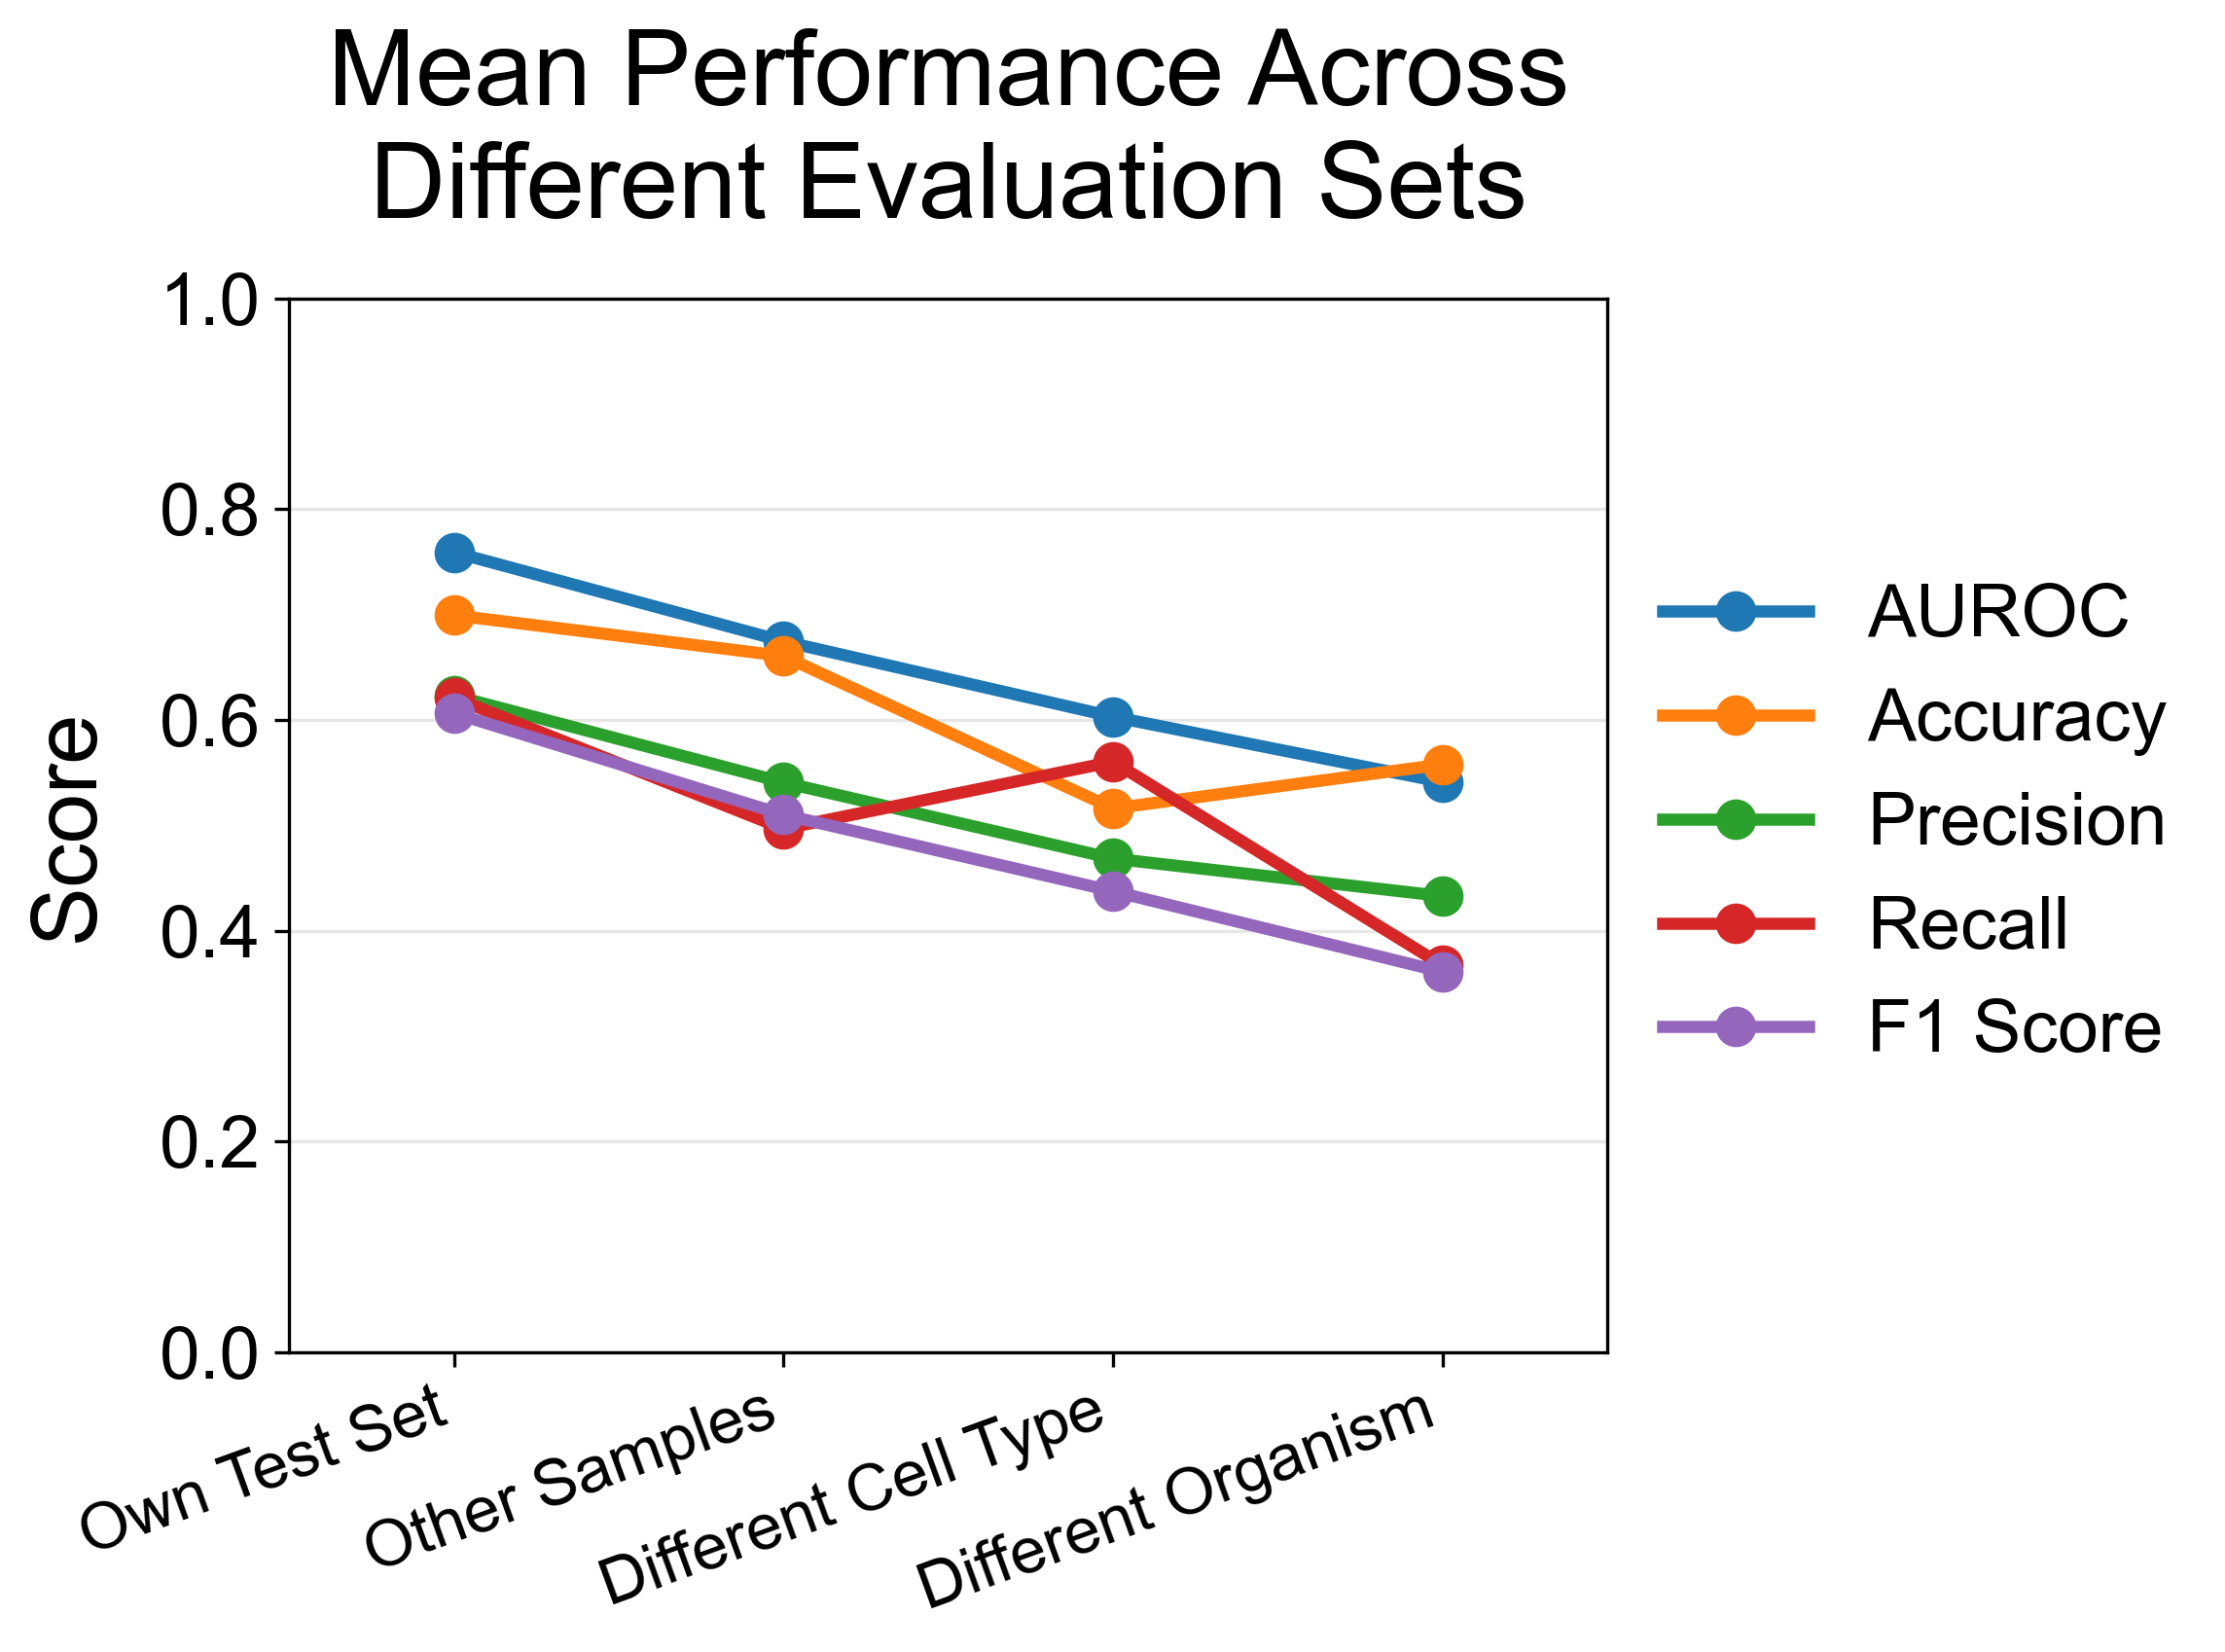

In [9]:
evaluation_order = [
    "Own Test Set",
    "Other Samples",
    "Different Cell Type",
    "Different Organism"
]

evaluation_sets = {
    "Own Test Set": own_test_set_group,
    "Other Samples": same_cell_type_group,
    "Different Cell Type": different_cell_type_group,
    "Different Organism": different_organism_group
}

metrics = {
    "auroc_mean": "AUROC",
    # "auprc_mean": "AUPRC",
    "accuracy_mean": "Accuracy",
    "precision_mean": "Precision",
    "recall_mean": "Recall",
    "f1_mean": "F1 Score"
}

summary_rows = []

for eval_name in evaluation_order:
    df = evaluation_sets[eval_name]
    row = {"Evaluation Set": eval_name}

    for metric_col in metrics:
        row[metric_col] = df[metric_col].mean()

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

x = np.arange(len(evaluation_order))

# Poster-friendly global settings
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 26,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

def plot_performance_across_evaluation_sets(summary_df, metrics, evaluation_order, save_path):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    for metric_col, label in metrics.items():
        ax.plot(
            x,
            summary_df[metric_col],
            marker="o",
            markersize=9,
            linewidth=3,
            label=label
        )

    ax.set_xticks(x)
    ax.set_xticklabels(evaluation_order, rotation=20, ha="right")

    # Pad x-axis so labels/points do not hit the edge
    ax.set_xlim(-0.5, len(evaluation_order) - 0.5)

    ax.set_title("Mean Performance Across\nDifferent Evaluation Sets", pad=20)
    # ax.set_xlabel("Evaluation Set", labelpad=12)
    ax.set_ylabel("Score", labelpad=12)
    ax.set_ylim(0, 1)

    ax.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0
    )

    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    
    return fig, ax

fig, ax = plot_performance_across_evaluation_sets(summary_df, metrics, evaluation_order, performance_across_evaluation_sets_plot_path)

fig.savefig(performance_across_evaluation_sets_plot_path, dpi=300, bbox_inches="tight")

plt.show()

### Own test set ROC - one graph per sample

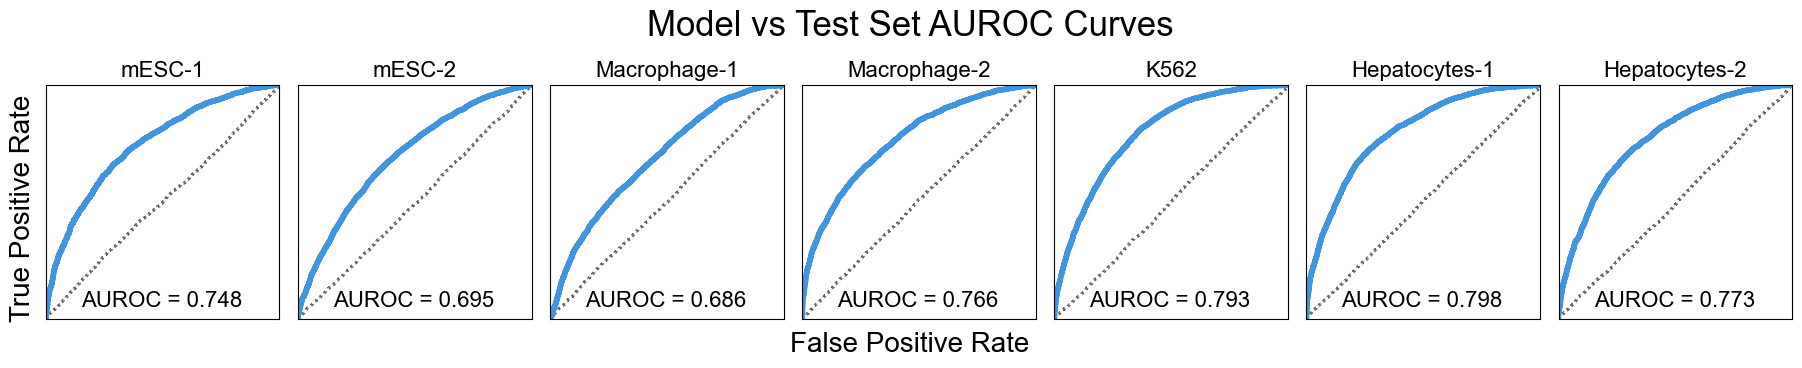

In [10]:
def plot_model_vs_test_set_auroc_curves(models_to_plot, auroc_models_vs_test_set_individual_plot_path):
    fig, ax = plt.subplots(1, 7, figsize=(18, 6))

    for i, sample_name in enumerate(models_to_plot):

        ax[i].set_aspect("equal")
        
        score_label_df = load_generalizability_df(sample_name, sample_name)
        scores = score_label_df["Score"].values
        labels = score_label_df["Label"].values
            
        rng = np.random.default_rng(42)
        rand_scores = rng.permutation(scores)

        fpr, tpr, thresholds = roc_curve(labels, scores)
        rand_fpr, rand_tpr, rand_thresholds = roc_curve(labels, rand_scores)
        auroc = roc_auc_score(labels, scores)

        ax[i].plot(
            fpr,
            tpr,
            lw=4,
            color="#4195df",
            label=f"AUROC = {auroc:.3f}",
            zorder=2,
        )

        ax[i].plot(
            rand_fpr,
            rand_tpr,
            color="black",
            linestyle=":",
            lw=2,
            alpha=0.6,
            zorder=1,
        )

        ax[i].set_title(
            sample_rename_map.get(sample_name, sample_name),
            fontsize=16,
        )

        ax[i].set_xlim(0, 1)
        ax[i].set_ylim(0, 1)

        ax[i].text(
            0.15,
            0.05,
            f"AUROC = {auroc:.3f}",
            transform=ax[i].transAxes,
            fontsize=16,
            bbox=dict(facecolor="none", edgecolor="none"),
        )

        ax[i].tick_params(bottom=False, left=False)
        ax[i].set_xticklabels([])
        ax[i].set_yticklabels([])

    fig.suptitle("Model vs Test Set AUROC Curves", fontsize=25, y=0.75)

    fig.text(
        0.5,
        0.18,
        "False Positive Rate",
        ha="center",
        fontsize=20,
    )

    fig.text(
        0.00,
        0.42,
        "True Positive Rate",
        va="center",
        rotation="vertical",
        fontsize=20,
    )

    fig.subplots_adjust(
        left=0.02,
        right=0.99,
        bottom=0.01,
        top=0.85,
        wspace=0.08,
    )
    
    return fig, ax

all_auroc_curve_fig, all_auroc_curve_ax = plot_model_vs_test_set_auroc_curves(
    models_to_plot, auroc_models_vs_test_set_individual_plot_path
    )

all_auroc_curve_fig.savefig(auroc_models_vs_test_set_individual_plot_path, dpi=300, bbox_inches="tight")

plt.show()

### Own test set ROC - All samples one fig

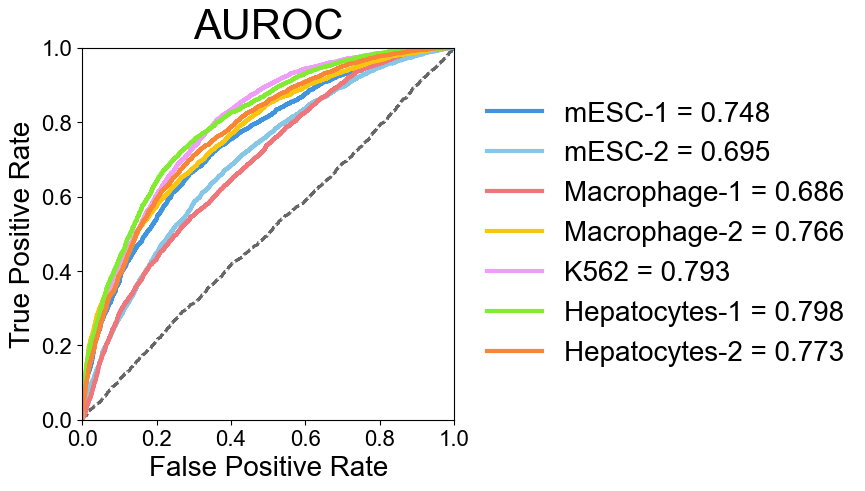

In [11]:
def plot_model_vs_test_set_auroc_combined(models_to_plot, auroc_models_vs_test_set_all_samples_plot_path):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_aspect("equal")

    rng = np.random.default_rng(42)
    random_curve_plotted = False

    for sample_name in models_to_plot:

        score_label_df = load_generalizability_df(sample_name, sample_name)
        scores = score_label_df["Score"].values
        labels = score_label_df["Label"].values

        labels = pd.to_numeric(pd.Series(labels), errors="coerce").to_numpy()
        scores = pd.to_numeric(pd.Series(scores), errors="coerce").to_numpy()

        valid_mask = ~np.isnan(labels) & ~np.isnan(scores)
        labels = labels[valid_mask].astype(int)
        scores = scores[valid_mask]

        fpr, tpr, _ = roc_curve(labels, scores)
        auroc = roc_auc_score(labels, scores)

        ax.plot(
            fpr,
            tpr,
            lw=3,
            color=sample_color_map.get(sample_name, None),
            label=f"{sample_rename_map.get(sample_name, sample_name)} = {auroc:.3f}",
        )

        # Plot one shuffled/random baseline only
        if not random_curve_plotted:
            rand_scores = rng.permutation(scores)
            rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)

            ax.plot(
                rand_fpr,
                rand_tpr,
                color="black",
                linestyle="--",
                lw=2,
                alpha=0.6,
                zorder=1,
            )

            random_curve_plotted = True


    ax.set_title("AUROC", fontsize=30)
    ax.set_xlabel("False Positive Rate", fontsize=20)
    ax.set_ylabel("True Positive Rate", fontsize=20)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=20,
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.72,
        bottom=0.10,
        top=0.90,
    )

    return fig, ax

all_auroc_combined_fig, all_auroc_combined_ax = plot_model_vs_test_set_auroc_combined(
    models_to_plot, auroc_models_vs_test_set_all_samples_plot_path
    )

all_auroc_combined_fig.savefig(
    auroc_models_vs_test_set_all_samples_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Own test set PRC - All samples one fig

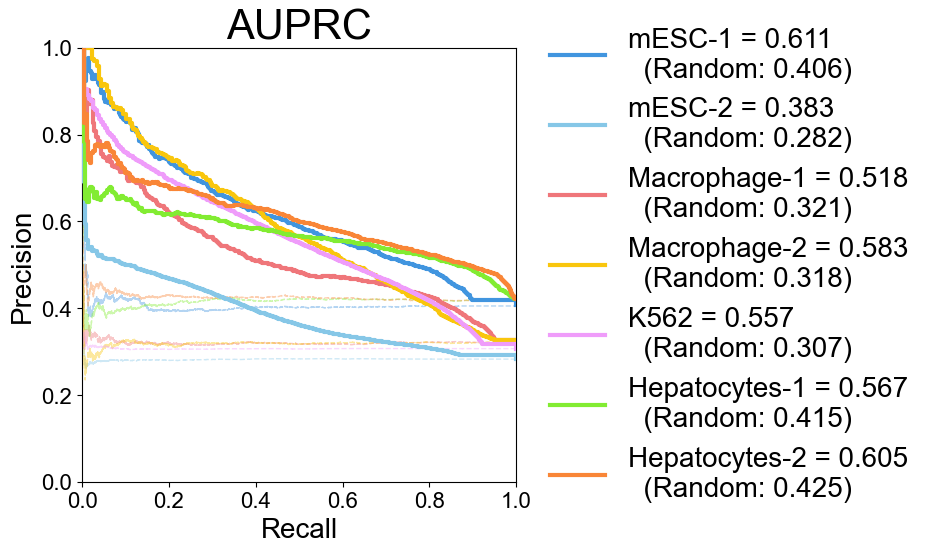

In [12]:
def plot_model_vs_test_set_auprc(auprc_all_method_dfs, models_to_plot, tf_tg_method_name):
    fig, ax = plt.subplots(figsize=(7, 6))

    rng = np.random.default_rng(42)
    
    def downsample_curve(x, y, max_points=500):
        x = np.asarray(x)
        y = np.asarray(y)

        if len(x) <= max_points:
            return x, y

        idx = np.linspace(0, len(x) - 1, max_points, dtype=int)
        idx = np.unique(idx)

        return x[idx], y[idx]

    for sample_name in models_to_plot:
        if sample_name not in auprc_all_method_dfs:
            logging.warning(
                f"Sample {sample_name} was not found in labeled AUPRC files. Skipping."
            )
            continue

        if tf_tg_method_name not in auprc_all_method_dfs[sample_name]:
            logging.warning(
                f"Method {tf_tg_method_name!r} not found for sample {sample_name}. "
                f"Available methods: {sorted(auprc_all_method_dfs[sample_name].keys())}"
            )
            continue

        auprc_df = auprc_all_method_dfs[sample_name][tf_tg_method_name].copy()

        labels = pd.to_numeric(auprc_df["_in_gt"], errors="coerce").to_numpy()
        scores = pd.to_numeric(auprc_df["Score"], errors="coerce").to_numpy()

        valid_mask = ~np.isnan(labels) & ~np.isnan(scores)
        labels = labels[valid_mask].astype(int)
        scores = scores[valid_mask]

        if len(np.unique(labels)) < 2:
            logging.warning(
                f"Sample {sample_name} has only one label class after filtering. Skipping."
            )
            continue
        
        precision, recall, _ = precision_recall_curve(labels, scores)
        auprc = average_precision_score(labels, scores)

        rand_scores = rng.permutation(scores)
        rand_precision, rand_recall, _ = precision_recall_curve(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)

        # sklearn returns recall in descending order, so reverse for cleaner left-to-right plotting
        plot_recall = recall[::-1]
        plot_precision = precision[::-1]

        plot_recall, plot_precision = downsample_curve(plot_recall, plot_precision)

        ax.step(
            plot_recall,
            plot_precision,
            where="post",
            lw=3,
            color=sample_color_map.get(sample_name, None),
            label=f"{sample_rename_map.get(sample_name, sample_name)} = {auprc:.3f}\n  (Random: {rand_auprc:.3f})",
            zorder=3,
        )

        # if not random_curve_plotted:
        ax.step(
            rand_recall[::-1],
            rand_precision[::-1],
            where="post",
            linestyle="--",
            lw=1,
            alpha=0.4,
            color=sample_color_map.get(sample_name, None),
            zorder=1,
        )

            # random_curve_plotted = True

    ax.set_title("AUPRC", fontsize=30)
    ax.set_xlabel("Recall", fontsize=20)
    ax.set_ylabel("Precision", fontsize=20)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=20,
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.72,
        bottom=0.10,
        top=0.90,
    )

    return fig, ax

auprc_all_method_dfs = load_auprc_grns_all_methods(sample_list=models_to_plot)

auprc_combined_vs_test_set_fig, auprc_combined_vs_test_set_ax = plot_model_vs_test_set_auprc(
    auprc_all_method_dfs, models_to_plot, OWN_MODEL_METHOD
    )

fig.savefig(
    auprc_models_vs_test_set_all_samples_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Own test set AUPRC Lift - All samples in one fig

/tmp/ipykernel_2442324/3618904234.py:67: RuntimeWarning: divide by zero encountered in divide
  precision_lift = precision_interp / rand_precision_interp
/tmp/ipykernel_2442324/3618904234.py:67: RuntimeWarning: divide by zero encountered in divide
  precision_lift = precision_interp / rand_precision_interp
/tmp/ipykernel_2442324/3618904234.py:67: RuntimeWarning: divide by zero encountered in divide
  precision_lift = precision_interp / rand_precision_interp


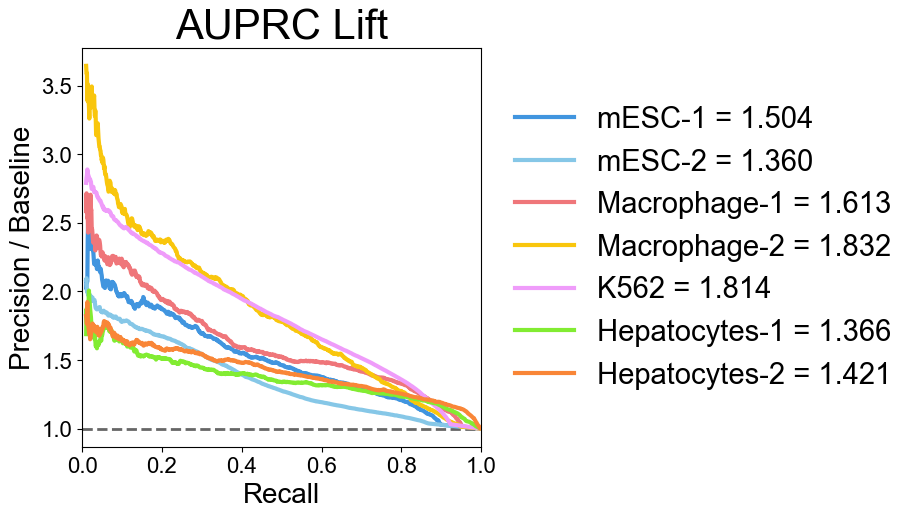

In [13]:
def plot_model_vs_test_set_auprc_lift(auprc_all_method_dfs, models_to_plot, tf_tg_method_name):
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.set_box_aspect(1)

    rng = np.random.default_rng(42)

    cell_type_method_auprc_lift = {
        "sample_name": [],
        "method": [],
        "auprc": [],
        "rand_auprc": [],
        "auprc_lift": [],
        "curve_lift_auc": [],
    }

    recall_grid = np.linspace(0, 1, 1000)

    for sample_name in models_to_plot:

        if sample_name not in auprc_all_method_dfs:
            logging.warning(f"Sample {sample_name} not found in auprc_all_method_dfs. Skipping.")
            continue

        if tf_tg_method_name not in auprc_all_method_dfs[sample_name]:
            logging.warning(
                f"Method {tf_tg_method_name} not found for sample {sample_name}. Skipping."
            )
            continue

        auprc_df = auprc_all_method_dfs[sample_name][tf_tg_method_name].copy()

        labels = pd.to_numeric(auprc_df["_in_gt"], errors="coerce").to_numpy()
        scores = pd.to_numeric(auprc_df["Score"], errors="coerce").to_numpy()

        valid_mask = ~np.isnan(labels) & ~np.isnan(scores)
        labels = labels[valid_mask].astype(int)
        scores = scores[valid_mask]

        if len(np.unique(labels)) < 2:
            logging.warning(
                f"Sample {sample_name} has only one label class after filtering. Skipping."
            )
            continue

        precision, recall, _ = precision_recall_curve(labels, scores)
        auprc = average_precision_score(labels, scores)

        rand_scores = rng.permutation(scores)
        rand_precision, rand_recall, _ = precision_recall_curve(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)

        # precision_recall_curve returns recall in descending order,
        # so reverse before interpolation.
        precision_interp = np.interp(
            recall_grid,
            recall[::-1],
            precision[::-1],
        )

        rand_precision_interp = np.interp(
            recall_grid,
            rand_recall[::-1],
            rand_precision[::-1],
        )

        precision_lift = precision_interp / rand_precision_interp
        
        rand_auprc_lift_baseline = 1.0  # The baseline for random AUPRC lift is always 1.0

        auprc_lift = auprc / rand_auprc
        curve_lift_auc = auc(recall_grid, precision_lift)

        cell_type_method_auprc_lift["sample_name"].append(sample_name)
        cell_type_method_auprc_lift["method"].append(tf_tg_method_name)
        cell_type_method_auprc_lift["auprc"].append(auprc)
        cell_type_method_auprc_lift["rand_auprc"].append(rand_auprc)
        cell_type_method_auprc_lift["auprc_lift"].append(auprc_lift)
        cell_type_method_auprc_lift["curve_lift_auc"].append(curve_lift_auc)

        min_recall_to_plot = 0.01

        plot_mask = recall_grid >= min_recall_to_plot

        ax.plot(
            recall_grid[plot_mask],
            precision_lift[plot_mask],
            lw=3,
            color=sample_color_map.get(sample_name, None),
            label=(
                f"{sample_rename_map.get(sample_name, sample_name)} "
                f"= {auprc_lift:.3f}"
            ),
            zorder=3,
        )


    ax.axhline(
        rand_auprc_lift_baseline,
        color="black",
        linestyle="--",
        lw=2,
        alpha=0.6,
        zorder=1,
    )

    ax.set_title("AUPRC Lift", fontsize=30)
    ax.set_xlabel("Recall", fontsize=20)
    ax.set_ylabel("Precision / Baseline", fontsize=20)

    ax.set_xlim(0, 1)
    # ax.set_ylim(-1, 1)

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=21,
    )

    fig.subplots_adjust(
        left=0.15,
        right=0.72,
        bottom=0.12,
        top=0.90,
    )
    
    return fig, ax

auprc_lift_combined_vs_test_set_fig, auprc_lift_combined_vs_test_set_ax = plot_model_vs_test_set_auprc_lift(
    auprc_all_method_dfs, models_to_plot, OWN_MODEL_METHOD
    )

auprc_lift_combined_vs_test_set_fig.savefig(
    auprc_lift_models_vs_test_set_all_samples_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Cross-trained model vs other inference methods

In [24]:
samples_to_run = [
    ("mESC", "E7.5_rep1", "mouse_hepatocytes", "hepatocytes_1"),
    ("mESC", "E8.5_rep1", "mouse_hepatocytes", "hepatocytes_1"),
    ("Macrophage", "buffer_1", "K562", "sample_1"),
    ("Macrophage", "buffer_2", "K562", "sample_1"),
    ("K562", "sample_1", "Macrophage", "buffer_1"),
    ("mouse_hepatocytes", "hepatocytes_1", "mESC", "E7.5_rep1"),
    ("mouse_hepatocytes", "hepatocytes_3", "mESC", "E7.5_rep1"),
]


def _is_binary_like(series):
    vals = pd.Series(series).dropna().unique()
    return len(vals) > 0 and set(vals).issubset({0, 1, 0.0, 1.0, True, False})


def standardize_prediction_score_label_df(df):
    """
    Makes cached/generated model prediction files consistent.

    Expected output:
        - Score column
        - _in_gt column when Source/Target are absent
    """
    df = df.copy()

    if "Score" not in df.columns and "score" in df.columns:
        df = df.rename(columns={"score": "Score"})

    if "_in_gt" not in df.columns:
        if "label" in df.columns:
            df["_in_gt"] = df["label"]
        elif "Label" in df.columns:
            df["_in_gt"] = df["Label"]

    # Handle accidentally reversed label/score columns.
    if "Score" in df.columns and "_in_gt" in df.columns:
        score_is_binary = _is_binary_like(df["Score"])
        label_is_binary = _is_binary_like(df["_in_gt"])

        if score_is_binary and not label_is_binary:
            old_score = df["Score"].copy()
            df["Score"] = df["_in_gt"]
            df["_in_gt"] = old_score

    if "_in_gt" in df.columns:
        df["_in_gt"] = df["_in_gt"].astype(int)

    return df


def load_or_generate_tftg_predictions(
    label_file,
    tf_dna_model_chkpt,
    tf_tg_model_chkpt,
    tf_embeddings_tensor,
    tf_mask_tensor,
    data_loader,
    device,
    tf_idx_to_name,
    tg_idx_to_name,
    compile_model=True,
):
    if label_file.exists():
        logging.info(f"    - Loading cached predictions from: {label_file.name}")
        prediction_df = pd.read_csv(label_file)
        return standardize_prediction_score_label_df(prediction_df)

    logging.info(f"    - Generating predictions and saving to: {label_file.name}")

    tf_tg_model = utils.load_tf_tg_regulation_model(
        tf_dna_model_chkpt,
        tf_tg_model_chkpt,
        tf_embeddings_tensor,
        tf_mask_tensor,
        compile_model=compile_model,
    )

    prediction_df = generate_model_predictions(
        tf_tg_model.model,
        data_loader,
        device,
        tf_idx_to_name,
        tg_idx_to_name,
    )

    prediction_df = standardize_prediction_score_label_df(prediction_df)

    label_file.parent.mkdir(parents=True, exist_ok=True)
    prediction_df.to_csv(label_file, index=False)

    return prediction_df

standardized_method_dfs = {}
label_by_method_dict = {}
score_by_method_dict = {}
metric_by_method_list = []
gt_by_sample_dict = {}

sample_list = [sample_name for _, sample_name, _, _ in samples_to_run]
auprc_all_method_dfs = load_auprc_grns_all_methods(sample_list=sample_list)

subset_size = 10_000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for model_cell_type, sample_name, cross_model_cell_type, cross_model_sample_name in samples_to_run:

    logging.info(
        f"Processing test sample: {sample_name} | "
        f"Test cell type: {model_cell_type} | "
        f"Cross-trained model: {cross_model_cell_type}/{cross_model_sample_name}"
    )

    cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"

    model_label_file = (
        score_label_save_dir
        / f"{sample_name}_model_vs_{sample_name}_grn_{subset_size}.csv"
    )

    cross_model_label_file = (
        score_label_save_dir
        / f"{cross_model_sample_name}_model_vs_{sample_name}_grn_{subset_size}.csv"
    )

    # Load cached test dataset for the evaluation/test sample.
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
        sample_name=sample_name,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type="test",
        subset_size=subset_size,
    )

    # Load full test labels / edge metadata.
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "tftg_inputs_test.pt",
        weights_only=False,
    )

    tf_idx_to_name, tg_idx_to_name = create_tf_tg_index_to_name_mappings(metadata)

    test_set_tf_indices = list(tftg_inputs_test["tf_idx"].numpy())
    test_set_tg_indices = list(tftg_inputs_test["tg_idx"].numpy())

    tf_names = [tf_idx_to_name[int(idx)].upper() for idx in test_set_tf_indices]
    tg_names = [tg_idx_to_name[int(idx)].upper() for idx in test_set_tg_indices]

    # -----------------------------
    # Own-model predictions
    # -----------------------------
    own_tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][sample_name]
    own_tf_dna_model_chkpt = config.tf_dna_model_checkpoints[model_cell_type]

    prediction_df = load_or_generate_tftg_predictions(
        label_file=model_label_file,
        tf_dna_model_chkpt=own_tf_dna_model_chkpt,
        tf_tg_model_chkpt=own_tf_tg_model_chkpt,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        data_loader=data_loader,
        device=device,
        tf_idx_to_name=tf_idx_to_name,
        tg_idx_to_name=tg_idx_to_name,
        compile_model=False,
    )

    # -----------------------------
    # Cross-trained model predictions
    # -----------------------------
    cross_tf_tg_model_chkpt = tf_tg_model_checkpoints[cross_model_cell_type][cross_model_sample_name]
    cross_tf_dna_model_chkpt = config.tf_dna_model_checkpoints[cross_model_cell_type]

    cross_model_prediction_df = load_or_generate_tftg_predictions(
        label_file=cross_model_label_file,
        tf_dna_model_chkpt=cross_tf_dna_model_chkpt,
        tf_tg_model_chkpt=cross_tf_tg_model_chkpt,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        data_loader=data_loader,
        device=device,
        tf_idx_to_name=tf_idx_to_name,
        tg_idx_to_name=tg_idx_to_name,
        compile_model=False,
    )

    # -----------------------------
    # Ground truth
    # -----------------------------
    tf_tg_label_df, gt_pairs, gt_tfs, gt_targets = create_tf_tg_label_df(tftg_inputs_test)

    gt_tfs = gt_tfs.intersection(set(tf_names))
    gt_targets = gt_targets.intersection(set(tg_names))

    gt_pairs = {
        pair
        for pair in gt_pairs
        if pair.split("\t")[0] in gt_tfs and pair.split("\t")[1] in gt_targets
    }

    gt_by_sample_dict[sample_name] = {
        "gt_pairs": gt_pairs,
        "gt_tfs": gt_tfs,
        "gt_targets": gt_targets,
        "test_cell_type": model_cell_type,
        "test_sample": sample_name,
    }

    # -----------------------------
    # Other method GRNs
    # -----------------------------
    OTHER_METHOD_MUON_DIR = Path(
        "/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns"
    )

    linger_path = (
        OTHER_METHOD_MUON_DIR
        / "LINGER_muon"
        / f"linger_{model_cell_type}_{sample_name}.tsv"
    )

    scenic_plus_path = (
        OTHER_METHOD_MUON_DIR
        / "SCENIC_muon"
        / f"scenicplus_{model_cell_type}_{sample_name}.tsv"
    )

    cell_oracle_path = (
        OTHER_METHOD_MUON_DIR
        / "CellOracle_muon"
        / f"celloracle_{model_cell_type}_{sample_name}.tsv"
    )

    pando_path = (
        OTHER_METHOD_MUON_DIR
        / "Pando_muon"
        / f"pando_{model_cell_type}_{sample_name}.tsv"
    )

    figr_path = (
        OTHER_METHOD_MUON_DIR
        / "FigR_muon"
        / f"figr_{model_cell_type}_{sample_name}.tsv"
    )

    method_info = {
        "SCENIC+": {
            "path": scenic_plus_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
        "LINGER": {
            "path": linger_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
        "CellOracle": {
            "path": cell_oracle_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
        "Pando": {
            "path": pando_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
        "FigR": {
            "path": figr_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
    }

    standardized_method_dfs[sample_name] = {}

    for method_name, info in method_info.items():
        df_std = load_and_standardize_method(method_name, info)

        mask = df_std["Source"].isin(gt_tfs) & df_std["Target"].isin(gt_targets)
        df_filtered = df_std.loc[mask].copy()

        standardized_method_dfs[sample_name][method_name] = df_filtered

    # Important:
    # Use stable method labels, not sample names.
    standardized_method_dfs[sample_name][OWN_MODEL_METHOD] = prediction_df
    standardized_method_dfs[sample_name][CROSS_MODEL_METHOD] = cross_model_prediction_df

    label_by_method_dict[sample_name] = {}
    score_by_method_dict[sample_name] = {}

    # -----------------------------
    # Metric computation
    # -----------------------------
    for method_name, df in standardized_method_dfs[sample_name].items():
        df = standardize_prediction_score_label_df(df)

        if "Source" in df.columns and "Target" in df.columns:
            labels = [
                1 if pair in gt_pairs else 0
                for pair in df["Source"] + "\t" + df["Target"]
            ]
        elif "_in_gt" in df.columns:
            labels = df["_in_gt"].astype(int).tolist()
        else:
            raise ValueError(
                f"{method_name} for {sample_name} has neither "
                "Source/Target columns nor an _in_gt label column."
            )

        scores = df["Score"].tolist()

        label_by_method_dict[sample_name][method_name] = labels
        score_by_method_dict[sample_name][method_name] = scores

        metrics_df = compute_metrics(
            method_name,
            sample_name,
            df,
            gt_pairs,
            score_threshold=0.5,
        )

        metrics_df["test_cell_type"] = model_cell_type
        metrics_df["test_sample"] = sample_name
        
        labeled_auprc_df = auprc_all_method_dfs[sample_name][method_name]
        metrics_df["auprc"] = average_precision_score(labeled_auprc_df["_in_gt"], labeled_auprc_df["Score"])
        metrics_df["rand_auprc"] = average_precision_score(labeled_auprc_df["_in_gt"], np.random.rand(len(labeled_auprc_df["_in_gt"])))
        
        if sample_name == "hepatocytes_1" and method_name == "Pando":
            metrics_df["auroc"] = roc_auc_score(labeled_auprc_df["_in_gt"], labeled_auprc_df["Score"])
            metrics_df["rand_auroc"] = roc_auc_score(labeled_auprc_df["_in_gt"], np.random.rand(len(labeled_auprc_df["_in_gt"])))

        if method_name == OWN_MODEL_METHOD:
            metrics_df["model_eval_type"] = "own_test_set"
            metrics_df["train_cell_type"] = model_cell_type
            metrics_df["train_sample"] = sample_name

        elif method_name == CROSS_MODEL_METHOD:
            metrics_df["model_eval_type"] = "cross_trained"
            metrics_df["train_cell_type"] = cross_model_cell_type
            metrics_df["train_sample"] = cross_model_sample_name

        else:
            metrics_df["model_eval_type"] = "external_method"
            metrics_df["train_cell_type"] = np.nan
            metrics_df["train_sample"] = np.nan

        metric_by_method_list.append(metrics_df)

        safe_method_name = (
            method_name
            .replace(" ", "_")
            .replace("/", "_")
            .replace("(", "")
            .replace(")", "")
        )

full_metric_df = pd.concat(metric_by_method_list, ignore_index=True)


INFO - Processing test sample: E7.5_rep1 | Test cell type: mESC | Cross-trained model: mouse_hepatocytes/hepatocytes_1
INFO -     - Loading cached predictions from: E7.5_rep1_model_vs_E7.5_rep1_grn_10000.csv
INFO -     - Loading cached predictions from: hepatocytes_1_model_vs_E7.5_rep1_grn_10000.csv
INFO - Processing test sample: E8.5_rep1 | Test cell type: mESC | Cross-trained model: mouse_hepatocytes/hepatocytes_1
INFO -     - Loading cached predictions from: E8.5_rep1_model_vs_E8.5_rep1_grn_10000.csv
INFO -     - Loading cached predictions from: hepatocytes_1_model_vs_E8.5_rep1_grn_10000.csv
INFO - Processing test sample: buffer_1 | Test cell type: Macrophage | Cross-trained model: K562/sample_1
INFO -     - Loading cached predictions from: buffer_1_model_vs_buffer_1_grn_10000.csv
INFO -     - Loading cached predictions from: sample_1_model_vs_buffer_1_grn_10000.csv
INFO - Processing test sample: buffer_2 | Test cell type: Macrophage | Cross-trained model: K562/sample_1
INFO -     -

In [26]:
# full_metric_df.to_csv(
#     full_metric_df_path,
#     index=False,
# )

standardized_method_dfs_path = RESULT_DIR / "model_generalizability" / "standardized_method_dfs.pkl"
with open(standardized_method_dfs_path, "wb") as f:
    pickle.dump(standardized_method_dfs, f)

In [ ]:
full_metric_df = pd.read_csv(
    full_metric_df_path
)

standardized_method_dfs_path = RESULT_DIR / "model_generalizability" / "standardized_method_dfs.pkl"
with open(standardized_method_dfs_path, "rb") as f:
    standardized_method_dfs = pickle.load(f)

### Metric performance by method boxplots

In [27]:
def _style_xticklabels(ax, originals, method_color_dict,
                       sample_rename_map=None, color_xticks=True,
                       rotation=45, fontsize=15):
    sample_rename_map = sample_rename_map or {}
    labels = [sample_rename_map.get(o, o) for o in originals]

    ax.set_xticks(range(len(originals)))
    ax.set_xticklabels(labels, rotation=rotation, ha="right",
                       fontsize=fontsize, rotation_mode="anchor")

    for tick, original in zip(ax.get_xticklabels(), originals):
        if original in TFTG_MODEL_METHODS:
            
            tick.set_fontsize(fontsize)
            if color_xticks:
                tick.set_color(method_color_dict.get(original, "black"))
            tick.set_path_effects([pe.withStroke(linewidth=0.6, foreground=tick.get_color())])
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")

In [28]:
def plot_method_box_and_whisker(
    full_metric_df, 
    selected_column, 
    method_color_dict, 
    sample_rename_map, 
    show_values_above_boxes=True
    ):
    
    metric_ordered_by_auroc = (
        full_metric_df
        .groupby("method_name")[selected_column]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    sanitized_name = selected_column.replace("_", " ").lower()
    if sanitized_name in ["auroc", "auprc"]:
        sanitized_name = sanitized_name.upper()
        sanitized_name = sanitized_name.replace("AU", "")
    else:
        sanitized_name = sanitized_name.capitalize()

    loosely_dashed = (5, (10, 3))
    
    fig = plt.figure(figsize=(7, 6))

    ax = sns.boxplot(
        data=full_metric_df, 
        x="method_name", 
        y=selected_column, 
        hue="method_name", 
        width=0.6,
        order=metric_ordered_by_auroc, 
        palette=method_color_dict,
        whiskerprops={"linestyle": loosely_dashed, "linewidth": 1},
        boxprops={"linewidth": 0},
        capprops={"linewidth": 1},
        medianprops={"linewidth": 1},
        showfliers=False
    )
    
    medians = (
        full_metric_df
        .groupby("method_name")[selected_column]
        .median()
        .reindex(metric_ordered_by_auroc)
    )

    for i, method in enumerate(metric_ordered_by_auroc):
        vals = full_metric_df.loc[full_metric_df["method_name"] == method, selected_column].dropna()
        q1, q3 = vals.quantile([0.25, 0.75])
        top = vals[vals <= q3 + 1.5 * (q3 - q1)].max()

        if show_values_above_boxes:
            annotation = f"{vals.median():.3f}"
        else:
            ranks = medians.rank(method="min", ascending=False).astype(int)
            annotation = str(ranks[method])

        ax.text(i, top + 0.02, annotation, ha="center", va="bottom", fontsize=12)

    _style_xticklabels(
        ax,
        metric_ordered_by_auroc,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
        color_xticks=True,
        rotation=45,
        fontsize=12
    )

    plt.title(f"{sanitized_name} by Method", fontsize=17)
    plt.xlabel("")
    plt.ylabel(sanitized_name, fontsize=14)
    plt.yticks(fontsize=14)
    
    plt.ylim((0, 1))
    
    plt.tight_layout()
    
    return fig, ax

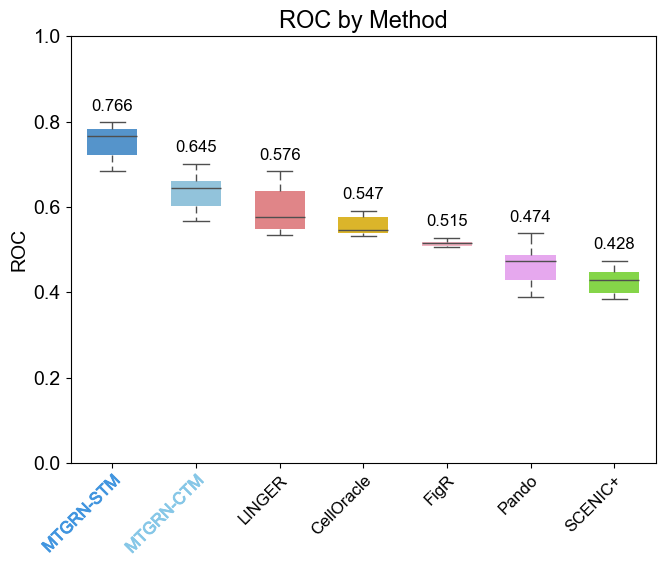

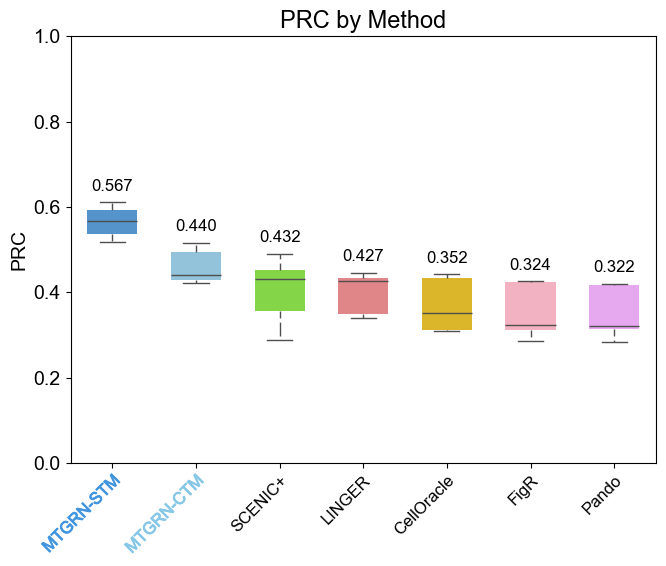

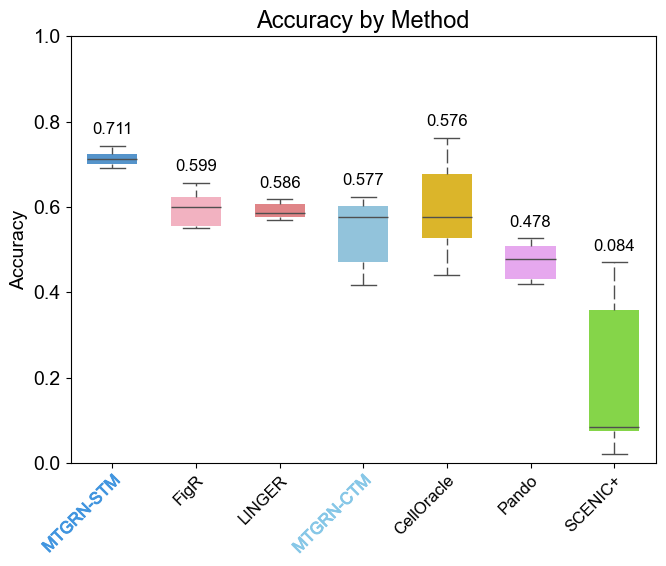

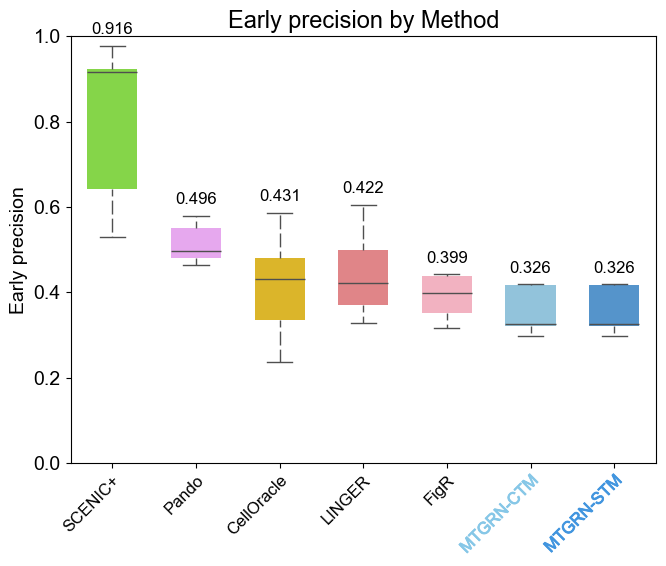

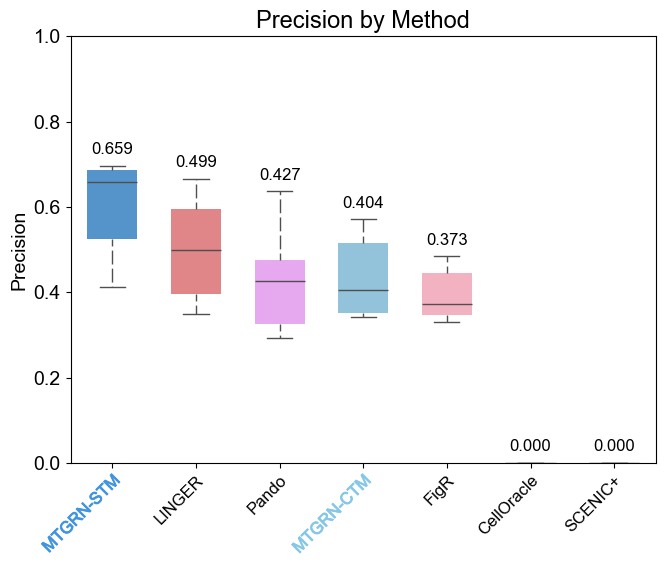

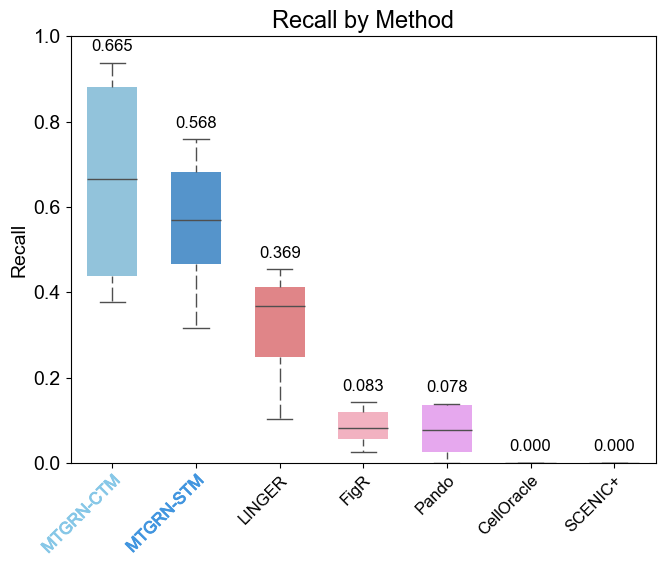

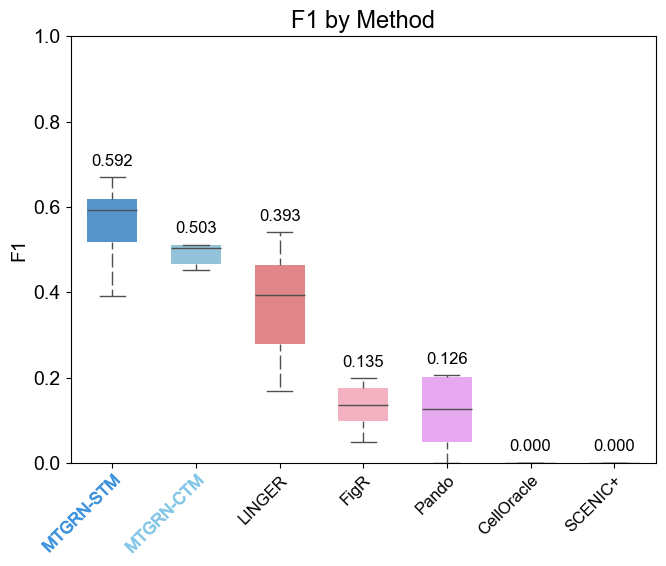

In [29]:
font_path = fm.findfont("Arial", fallback_to_default=False)

# Selected columns by method box and whisker plot
methods = ["auroc", "auprc", "accuracy", "early_precision", "precision", "recall", "f1"]

method_box_and_whisker_plots = {}
for selected_column in methods:
    
    sanitized_name = selected_column.replace("_", " ").lower()
    if sanitized_name in ["auroc", "auprc"]:
        sanitized_name = sanitized_name.upper()
        sanitized_name = sanitized_name.replace("AU", "")
    else:
        sanitized_name = sanitized_name.capitalize()

    method_comparison_boxplot_fig, method_comparison_boxplot_ax = plot_method_box_and_whisker(
        full_metric_df, 
        selected_column, 
        method_color_dict, 
        sample_rename_map, 
        show_values_above_boxes=True
    )
    
    method_box_and_whisker_plots[selected_column] = (method_comparison_boxplot_fig, method_comparison_boxplot_ax)

    plt.savefig(
        method_comparison_boxplot_dir / f"{sanitized_name.lower()}_by_method_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### ROC curves

In [30]:
def get_labels_and_scores_for_roc(df, gt_pairs):
    """
    Returns labels and scores for either:
      1. TF-TG model prediction dfs with _in_gt and Score columns
      2. External method GRN dfs with Source, Target, and Score columns
    """
    df = df.copy()

    if "Score" not in df.columns and "score" in df.columns:
        df = df.rename(columns={"score": "Score"})

    if "Score" not in df.columns:
        raise ValueError("DataFrame is missing a Score column.")

    if "_in_gt" in df.columns:
        labels = df["_in_gt"].astype(int).to_numpy()

    elif "Source" in df.columns and "Target" in df.columns:
        pairs = df["Source"].astype(str) + "\t" + df["Target"].astype(str)
        labels = pairs.isin(gt_pairs).astype(int).to_numpy()

    else:
        raise ValueError(
            "DataFrame must have either _in_gt or Source/Target columns."
        )

    scores = df["Score"].astype(float).to_numpy()

    valid_mask = np.isfinite(labels) & np.isfinite(scores)
    labels = labels[valid_mask]
    scores = scores[valid_mask]

    return labels, scores

def plot_sample_roc_curves(
    sample_name,
    standardized_method_dfs,
    gt_by_sample_dict,
    method_color_dict,
    sample_rename_map,
    roc_plot_dir,
    method_display_name_map=None,
    figsize=(6, 6),
):
    if method_display_name_map is None:
        method_display_name_map = {}

    if sample_name not in standardized_method_dfs:
        raise KeyError(f"Sample {sample_name} not found in standardized_method_dfs")

    if sample_name not in gt_by_sample_dict:
        raise KeyError(f"Sample {sample_name} not found in gt_by_sample_dict")

    sample_title = sample_rename_map.get(sample_name, sample_name)
    gt_pairs = gt_by_sample_dict[sample_name]["gt_pairs"]

    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    ax.set_box_aspect(1)

    cell_type_method_auroc = {
        "sample_name": [],
        "method": [],
        "auroc": [],
    }

    auroc_text_lines = []

    for method, df in standardized_method_dfs[sample_name].items():
        if method not in method_color_dict:
            continue

        y_roc, s_roc = get_labels_and_scores_for_roc(df, gt_pairs)

        if len(np.unique(y_roc)) < 2:
            logging.warning(
                f"Skipping ROC for {sample_name} / {method}: only one class present."
            )
            continue

        fpr, tpr, _ = roc_curve(y_roc, s_roc)
        auroc = roc_auc_score(y_roc, s_roc)

        cell_type_method_auroc["sample_name"].append(sample_name)
        cell_type_method_auroc["method"].append(method)
        cell_type_method_auroc["auroc"].append(auroc)

        method_color = method_color_dict.get(method, "#747474")
        auroc_text_lines.append((method, auroc, method_color))

        line_weight = 3.5 if method in TFTG_MODEL_METHODS else 2

        ax.plot(
            fpr,
            tpr,
            lw=line_weight,
            color=method_color,
            label="",
            zorder=3 if method in TFTG_MODEL_METHODS else 2,
        )

    # ROC random baseline
    ax.plot(
        [0, 1],
        [0, 1],
        lw=2,
        linestyle="--",
        color="black",
        alpha=0.6,
        zorder=1,
    )

    auroc_text_lines_sorted = sorted(
        auroc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.set_title(sample_title, fontsize=26)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(labelsize=18)

    legend_rows = []

    for method, auroc, method_color in auroc_text_lines_sorted:
        display_method = method_display_name_map.get(method, method)

        color_box = DrawingArea(16, 16, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                18,
                18,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.75,
            )
        )

        label_text = TextArea(
            f"{display_method} = {auroc:.3f}",
            textprops=dict(
                color="black",
                fontsize=18,
                fontweight="bold" if method in TFTG_MODEL_METHODS else "normal",
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0.1,
            sep=6,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=8,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.22),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    fig.text(
        0.5,
        -0.05,
        "False Positive Rate",
        ha="center",
        fontsize=24,
    )

    fig.text(
        -0.05,
        0.45,
        "True Positive Rate",
        va="center",
        rotation="vertical",
        fontsize=24,
    )

    fig.subplots_adjust(
        left=0.04,
        right=0.98,
        bottom=0.10,
        top=0.88,
        wspace=0.08,
    )

    roc_plot_dir = Path(roc_plot_dir)
    
    fig.savefig(
        roc_plot_dir / f"{sample_name}_auroc.png",
        dpi=300,
        bbox_inches="tight",
    )

    return fig, ax

def plot_sample_prc_curves(
    sample_name,
    auprc_all_method_dfs,
    method_color_dict,
    sample_rename_map,
    plot_lift=False,
):
    sample_title = sample_rename_map.get(sample_name, sample_name)

    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(6, 6),
        sharex=True,
        sharey=True,
    )

    ax.set_box_aspect(1)

    if sample_name not in auprc_all_method_dfs:
        raise KeyError(f"Sample {sample_name} not found in auprc_all_method_dfs")

    auprc_text_lines = []
    auprc_metric_rows = []

    for method in auprc_all_method_dfs[sample_name].keys():
        if method not in method_color_dict:
            continue
        
        auprc_df = auprc_all_method_dfs[sample_name][method]

        y_auprc = auprc_df["_in_gt"].astype(int).to_numpy()
        s_auprc = auprc_df["Score"].astype(float).to_numpy()

        if len(np.unique(y_auprc)) < 2:
            auprc = np.nan
            rand_auprc = np.nan
            continue

        auprc = average_precision_score(y_auprc, s_auprc)
        prec, rec, _ = precision_recall_curve(y_auprc, s_auprc)

        rand_scores = plotting_utils._create_random_distribution(s_auprc)
        rand_prec, rand_rec, _ = precision_recall_curve(y_auprc, rand_scores)
        rand_auprc = average_precision_score(y_auprc, rand_scores)

        auprc_metric_rows.append({
            "sample_name": sample_name,
            "method": method,
            "auprc": auprc,
            "rand_auprc": rand_auprc,
        })
        
        method_color = method_color_dict.get(method, "#747474")
        
        if plot_lift:
            auprc_lift = auprc / rand_auprc if rand_auprc > 0 else np.nan
            auprc_text_lines.append((method, auprc_lift, method_color))
        else:
            auprc_text_lines.append((method, auprc, method_color))

        line_weight = 3 if method in [OWN_MODEL_METHOD, CROSS_MODEL_METHOD] else 2
        
        if plot_lift:
            rand_prec_on_real_rec = interpolate_precision_at_recall(
                source_rec=rand_rec,
                source_prec=rand_prec,
                target_rec=rec,
            )

            precision_lift = prec / np.clip(rand_prec_on_real_rec, 1e-12, None)

            y_vals = rec
            x_vals = precision_lift

            rand_y_vals = rec
            rand_x_vals = np.ones_like(rec)

        else:
            y_vals = rec
            x_vals = prec

            rand_y_vals = rand_rec
            rand_x_vals = rand_prec
        

        ax.step(
            y_vals,
            x_vals,
            where="post",
            lw=line_weight,
            color=method_color,
            label="",
            zorder=3,
        )

        ax.step(
            rand_y_vals,
            rand_x_vals,
            where="post",
            lw=1,
            linestyle="--",
            color=method_color,
            label="",
            zorder=3,
            alpha=0.75,
        )

    auprc_text_lines_sorted = sorted(
        auprc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )



    ax.tick_params(labelsize=18)

    legend_rows = []

    for method, auprc, method_color in auprc_text_lines_sorted:
        color_box = DrawingArea(16, 16, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                18,
                18,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.75,
            )
        )

        label_text = TextArea(
            f"{method} = {auprc:.3f}",
            textprops=dict(
                color="black",
                fontsize=18,
                fontweight="bold" if method in TFTG_MODEL_METHODS else "normal",
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0.1,
            sep=6,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=8,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.22),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    fig.text(
        0.5,
        -0.05,
        "Recall",
        ha="center",
        fontsize=24,
    )

    if plot_lift:
        ylabel = "Precision / Random Baseline"
    else:
        ylabel = "Precision"
        
    fig.text(
        -0.05,
        0.45,
        ylabel,
        va="center",
        rotation="vertical",
        fontsize=24,
    )
    
    ax.set_title(sample_title, fontsize=26)
    ax.set_xlim(0, 1)
    if not plot_lift:
        ax.set_ylim(0, 1)

    fig.subplots_adjust(
        left=0.04,
        right=0.98,
        bottom=0.10,
        top=0.88,
        wspace=0.08,
    )

    return fig, ax

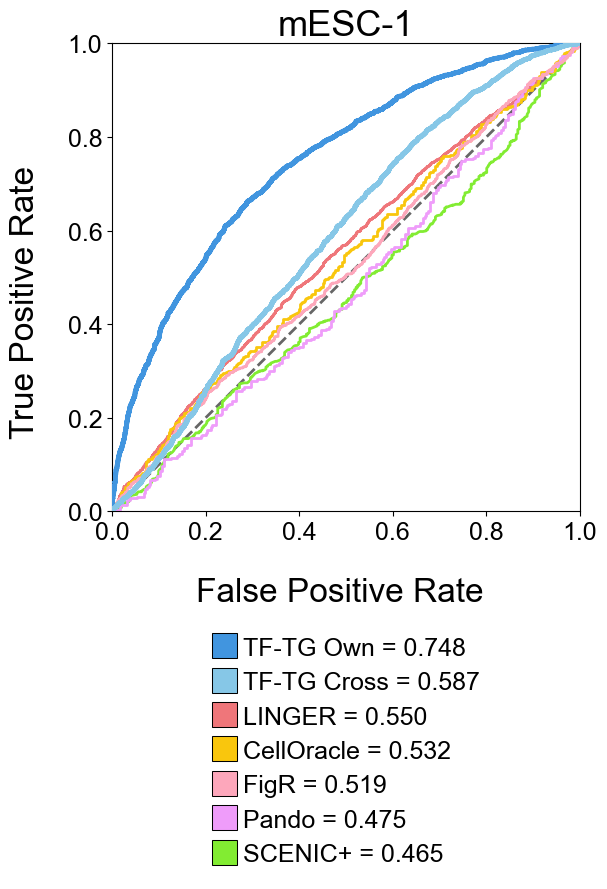

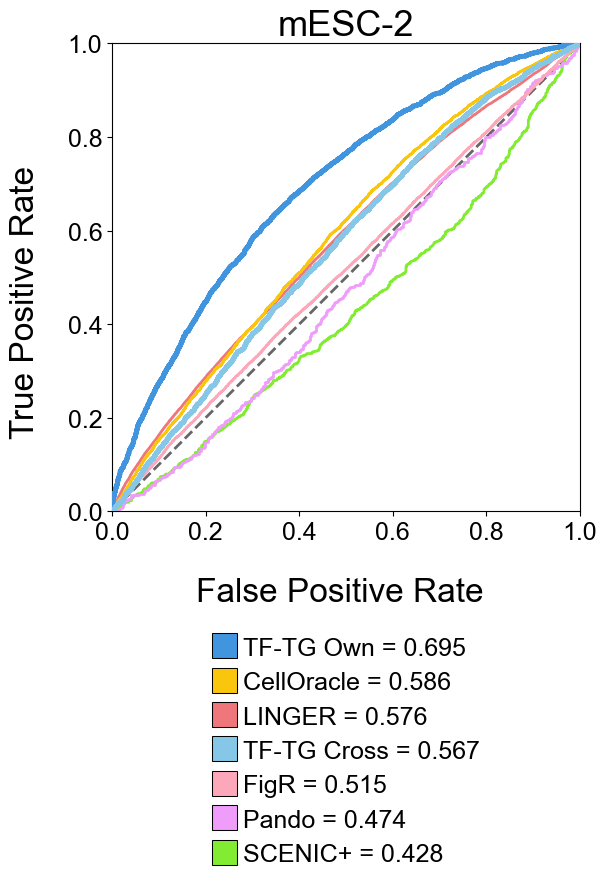

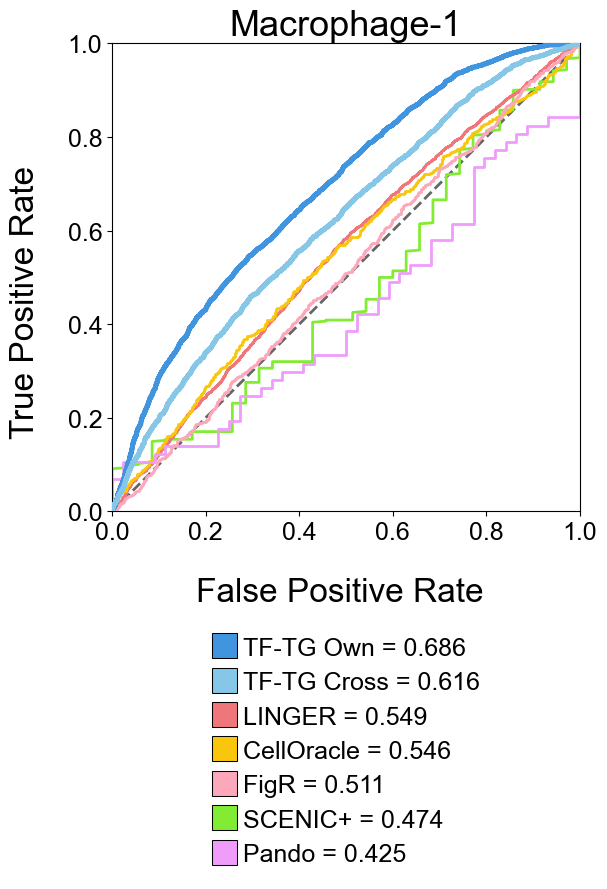

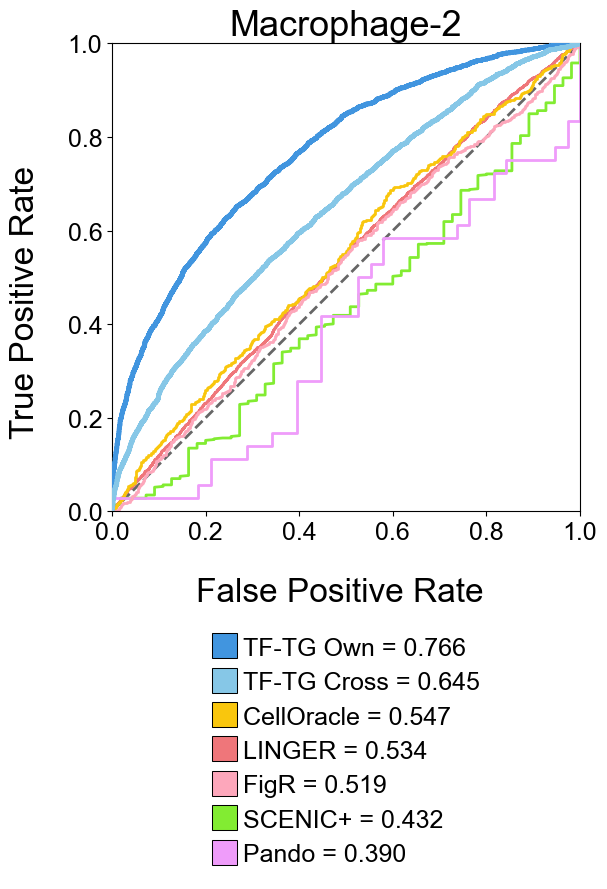

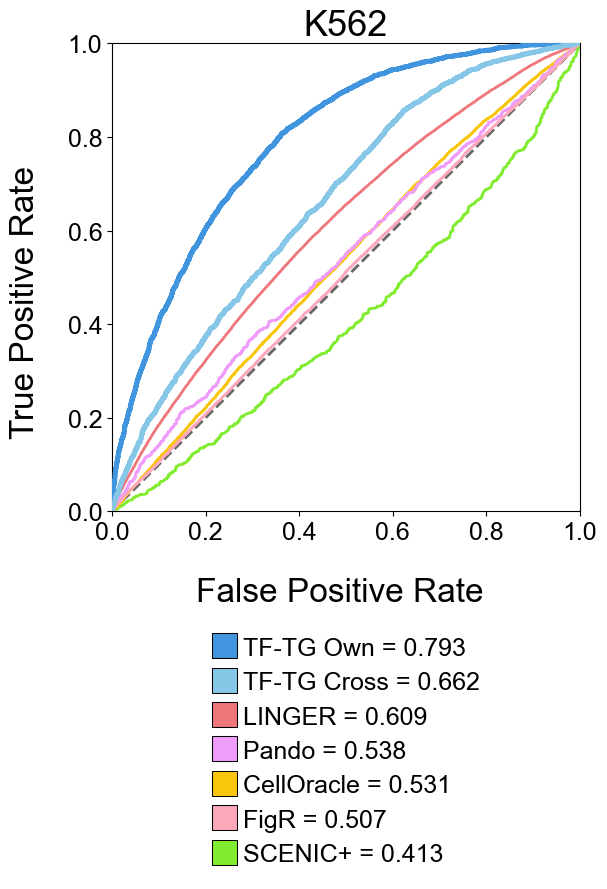

WARNING - Skipping ROC for hepatocytes_1 / Pando: only one class present.


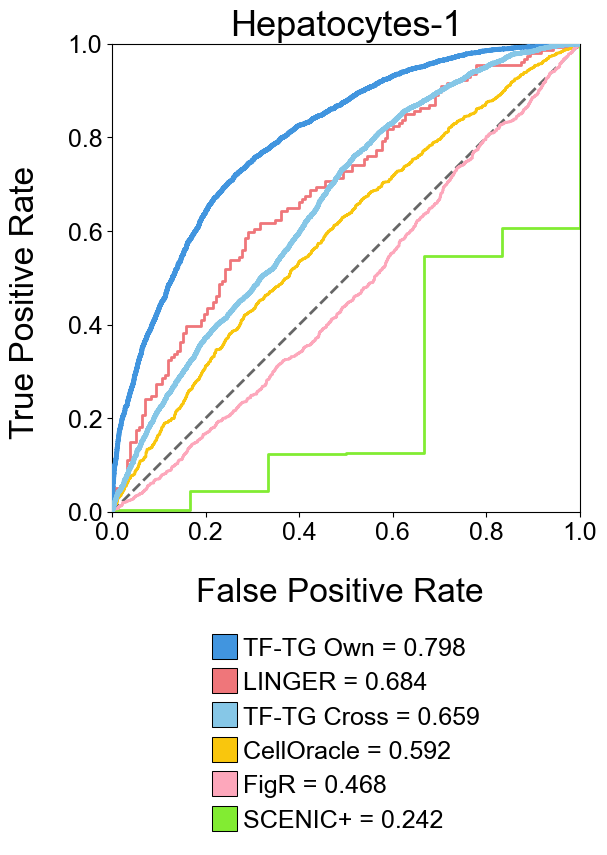

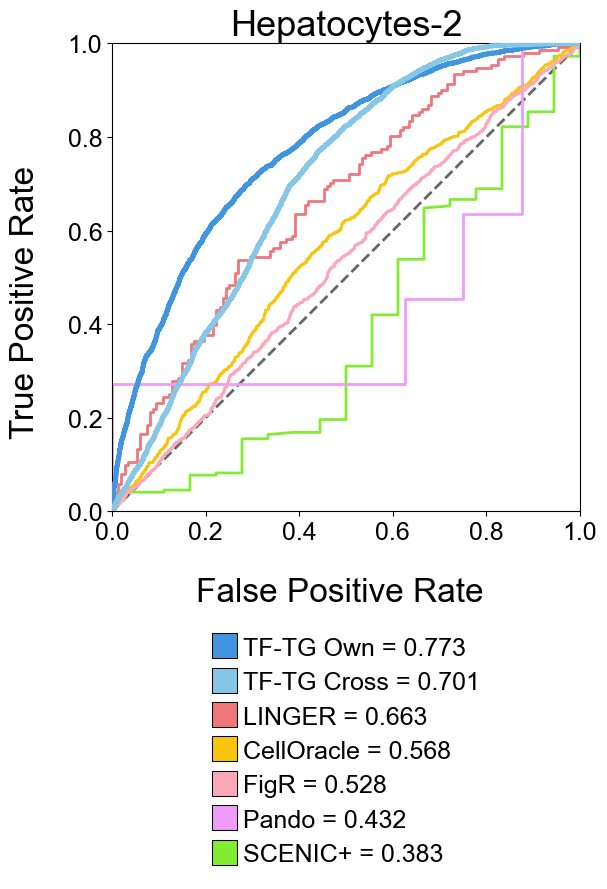

In [ ]:

sample_roc_curves = {}
for sample_name in sample_order:
    if sample_name not in standardized_method_dfs:
        continue

    fig, ax = plot_sample_roc_curves(
        sample_name=sample_name,
        standardized_method_dfs=standardized_method_dfs,
        gt_by_sample_dict=gt_by_sample_dict,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
        roc_plot_dir=roc_plot_dir,
        method_display_name_map=method_display_name_map,
        figsize=(6, 6),
    )
    
    sample_roc_curves[sample_name] = (fig, ax)

    plt.show()
    
    fig.savefig(model_vs_other_method_roc_curve_fig_dir / f"{sample_name}_auroc.png", dpi=300, bbox_inches="tight")

### PRC Curves

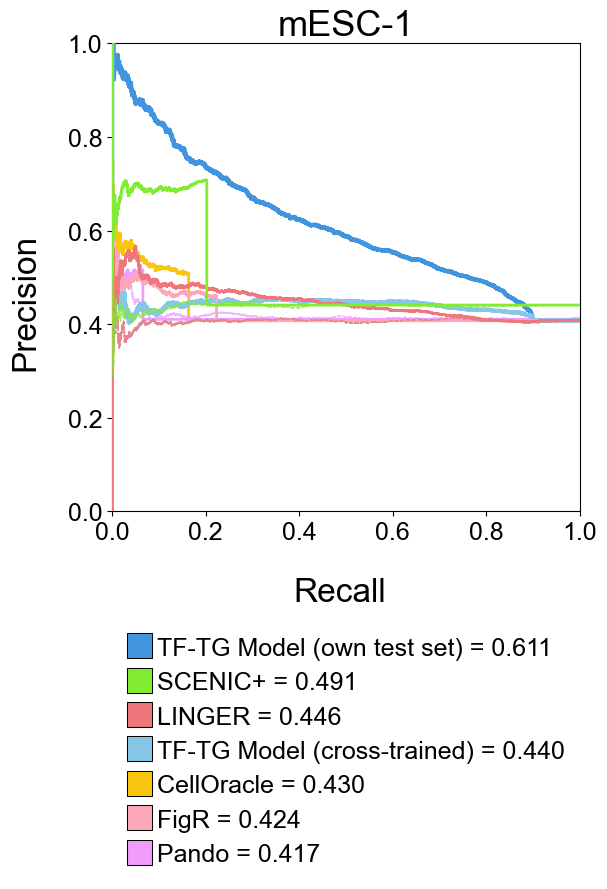

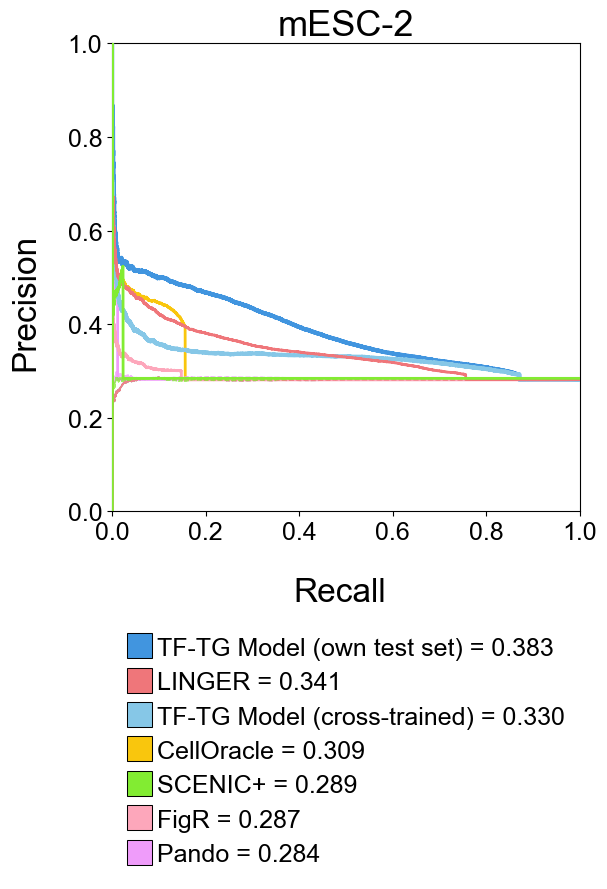

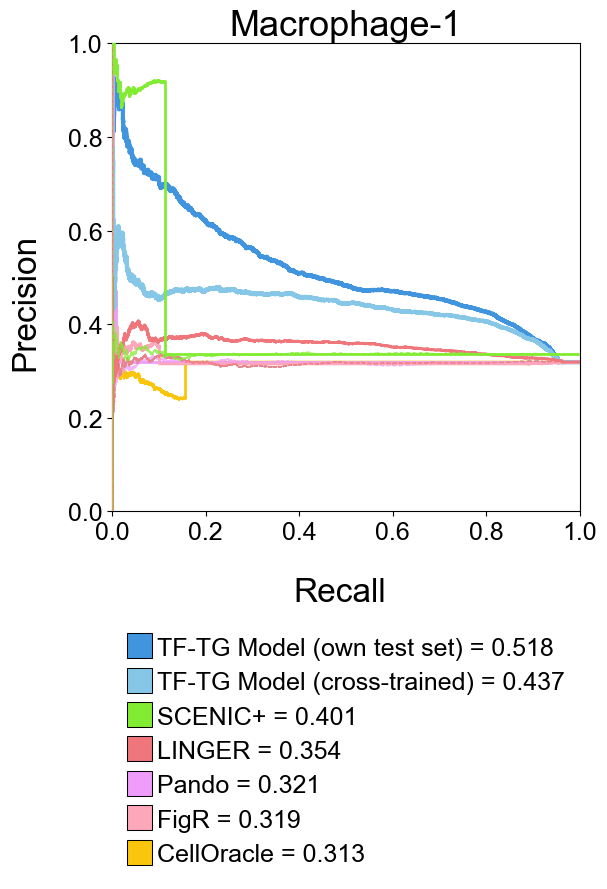

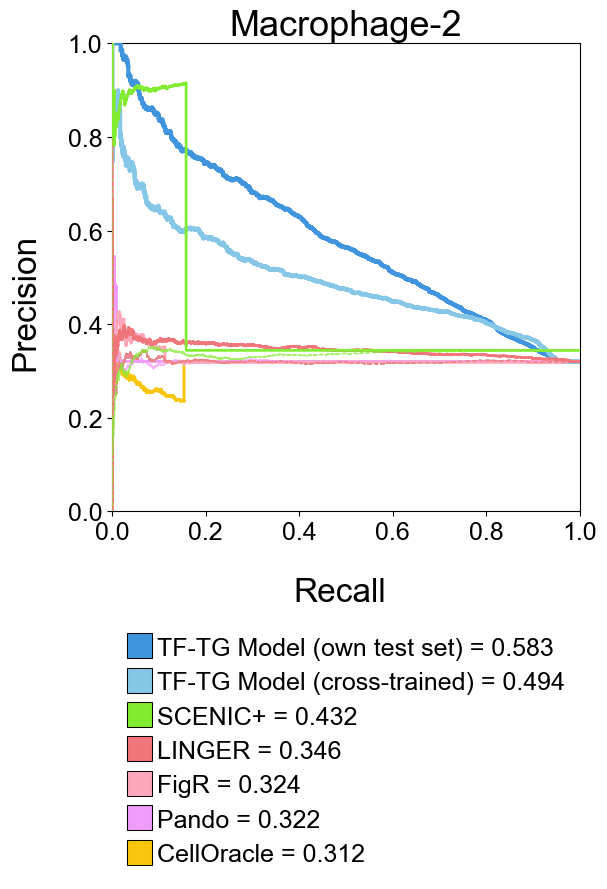

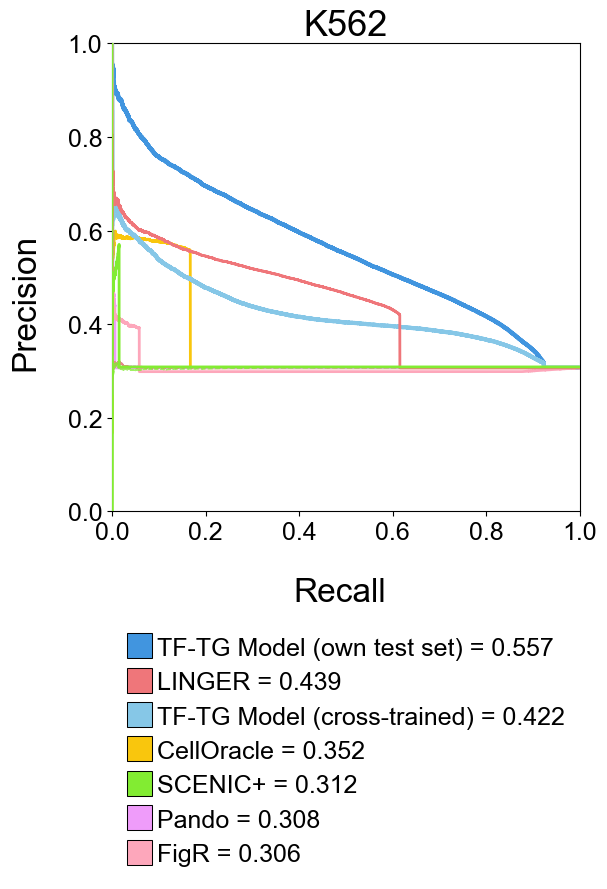

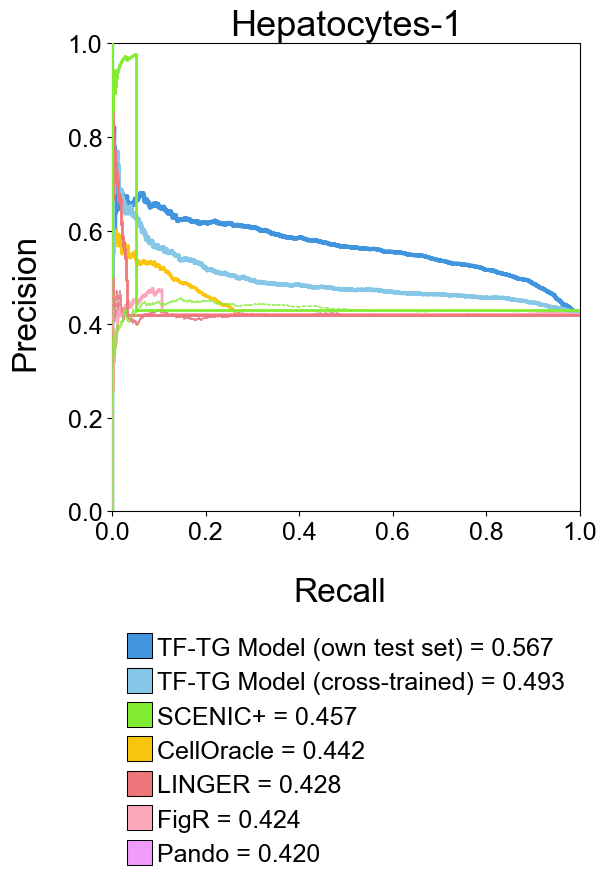

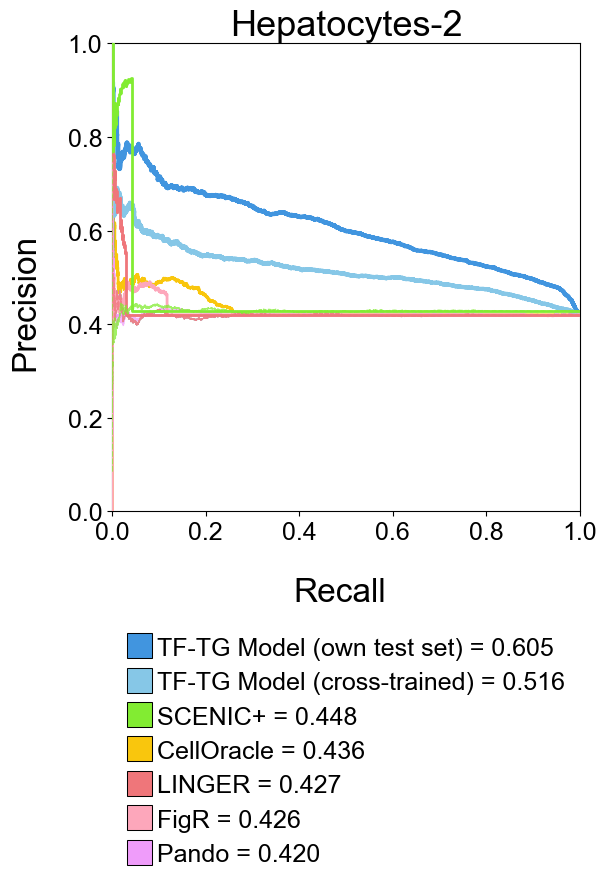

In [32]:
for sample_name in sample_order:
    if sample_name not in auprc_all_method_dfs:
        continue
    
    fig, sample_auprc_df = plot_sample_prc_curves(
        sample_name=sample_name,
        auprc_all_method_dfs=auprc_all_method_dfs,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
    )
    
    plt.show()

    
    fig.savefig(model_vs_other_method_prc_curve_fig_dir / f"{sample_name}_auprc.png", dpi=300, bbox_inches="tight")

### PRC lift curves

In [33]:
early_auprc_all_method_dfs = {}
for sample_name in sample_order:
    if sample_name not in auprc_all_method_dfs:
        continue
    
    early_auprc_all_method_dfs[sample_name] = {}
    
    for method in auprc_all_method_dfs[sample_name].keys():
        if method not in method_color_dict:
            continue
        
        early_auprc_all_method_dfs[sample_name][method] = {}
        
        auprc_df = auprc_all_method_dfs[sample_name][method]

        auprc_df_sorted = auprc_df.sort_values(by="Score", ascending=False)
        top_ten_percent_count = int(0.1 * len(auprc_df_sorted))
        auprc_df_top_10_pct = auprc_df_sorted.head(top_ten_percent_count).copy()  # Top 10% of edges
        
        early_auprc_all_method_dfs[sample_name][method] = auprc_df_top_10_pct

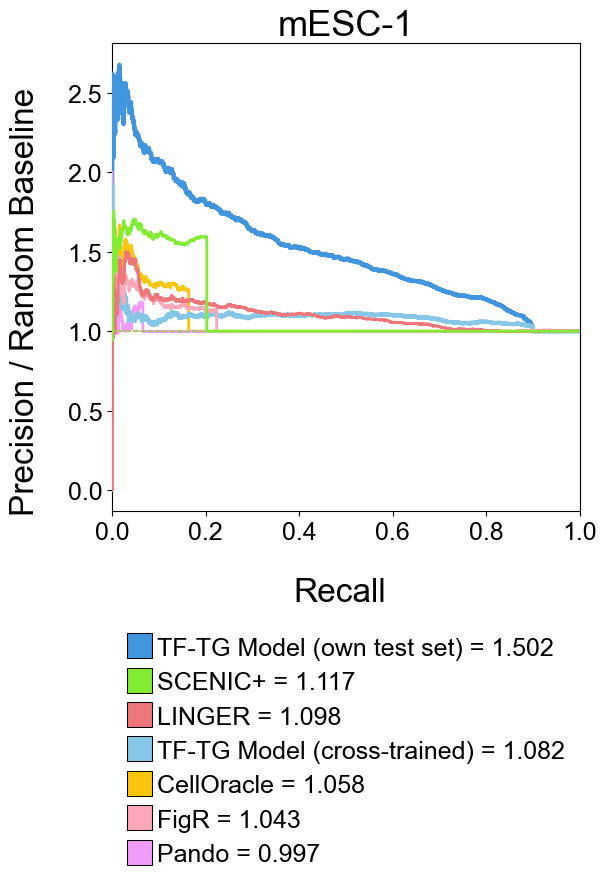

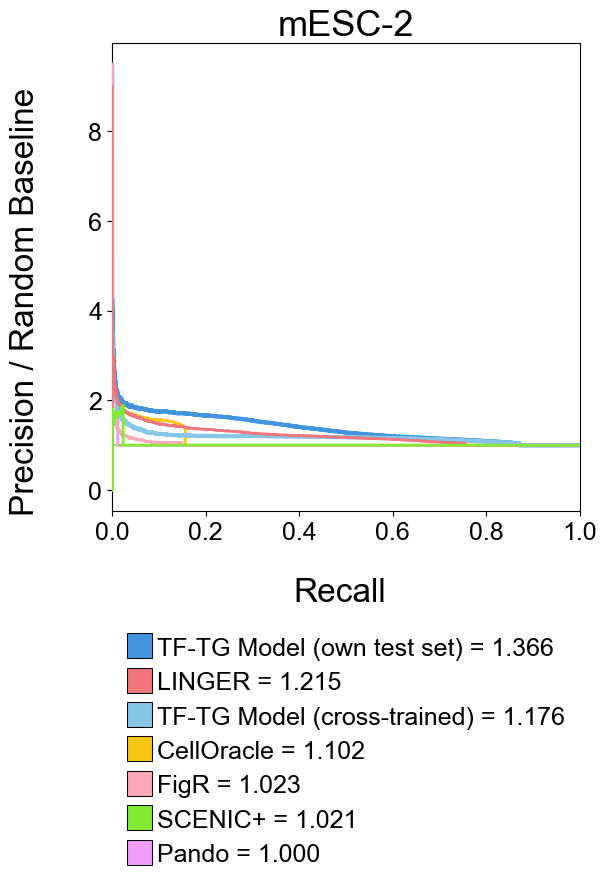

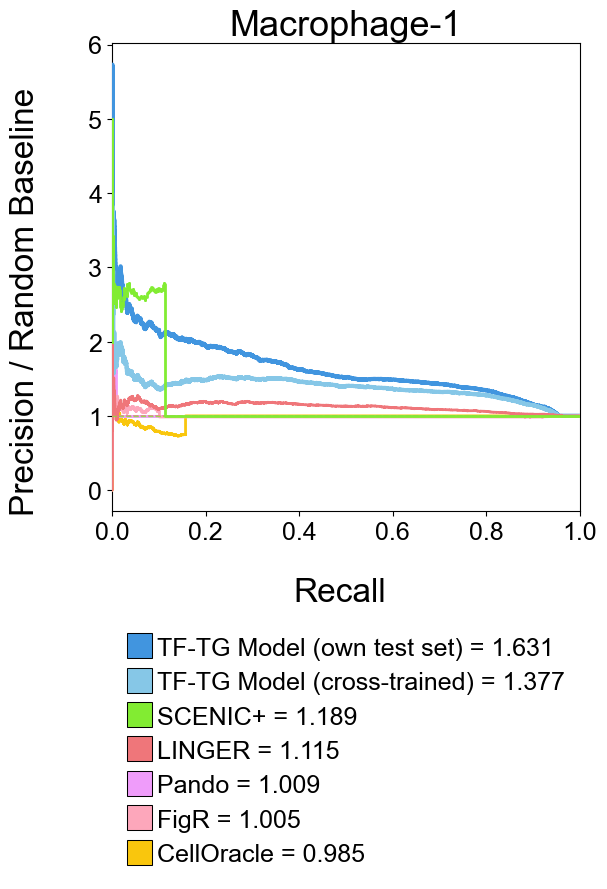

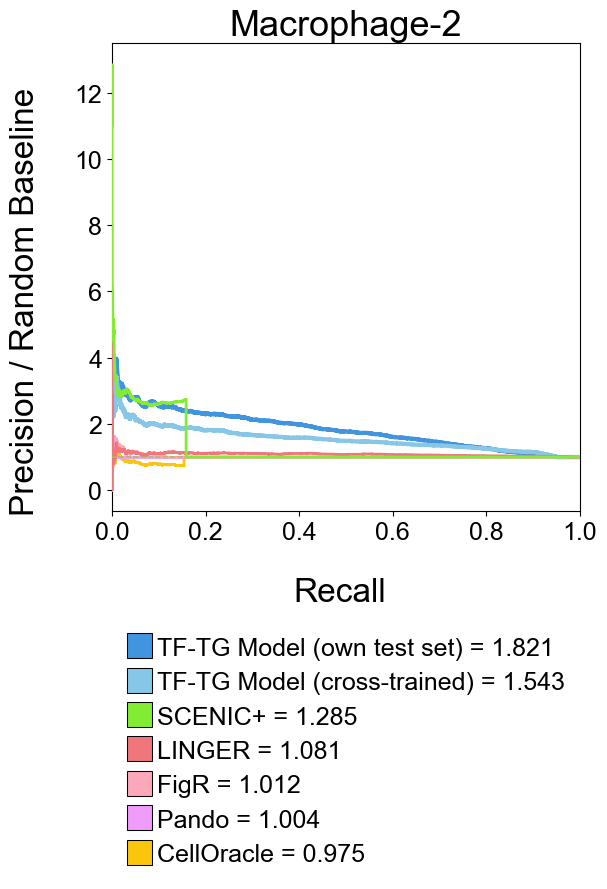

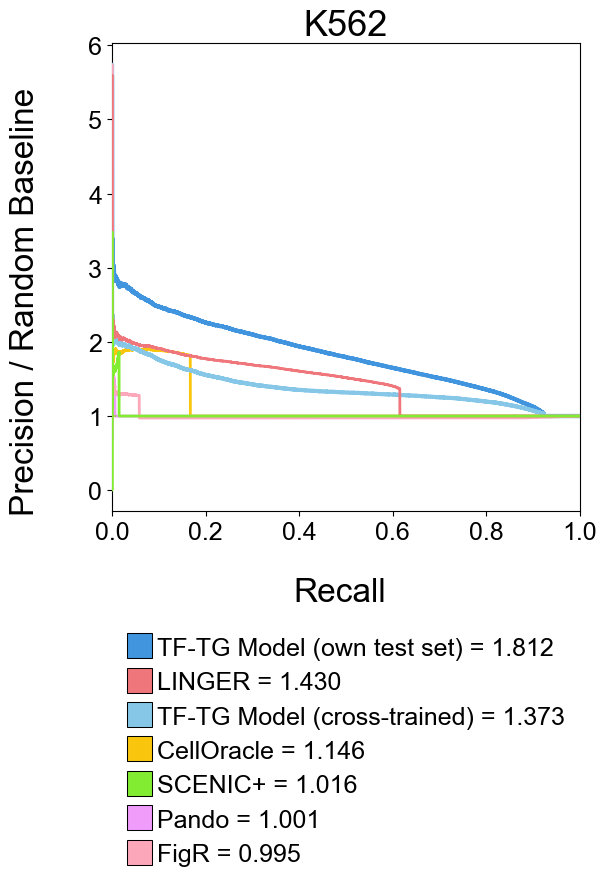

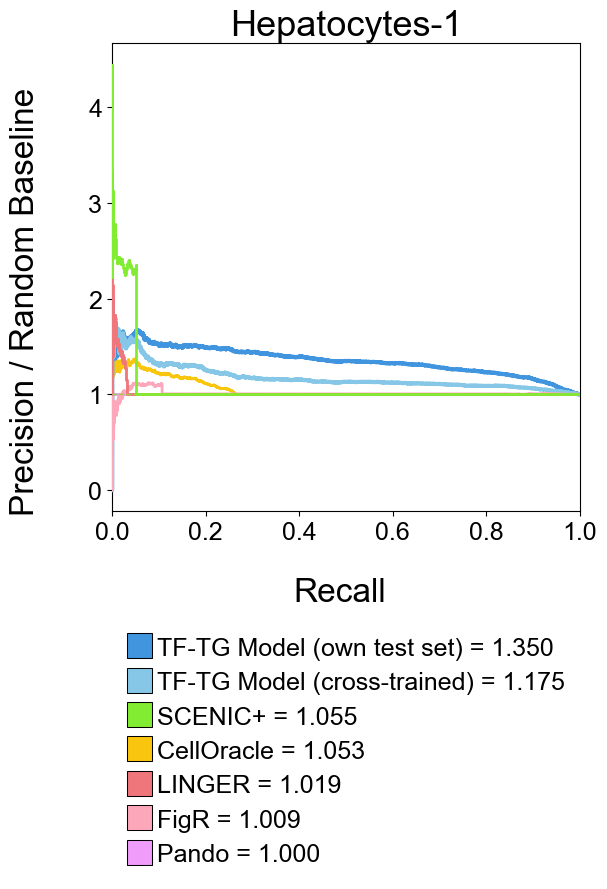

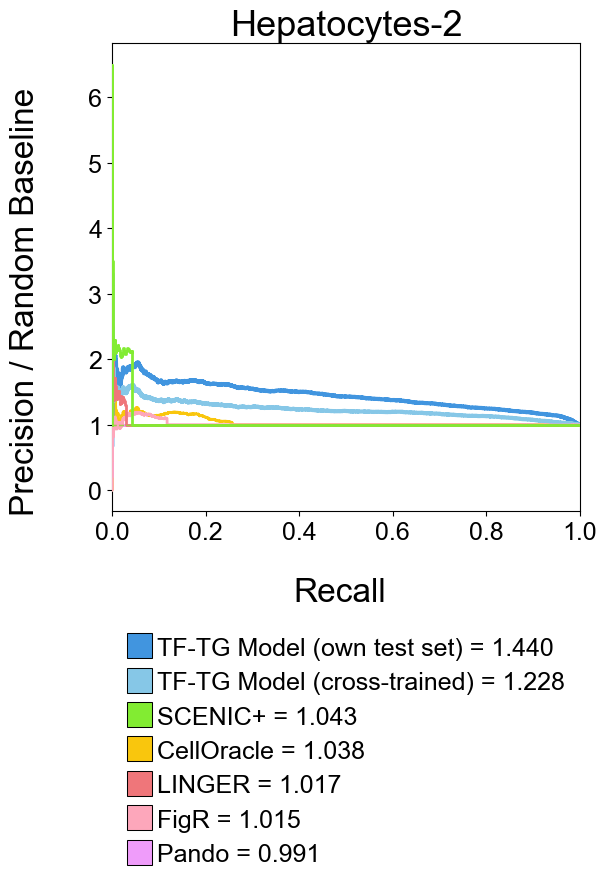

In [34]:
for sample_name in sample_order:
    if sample_name not in auprc_all_method_dfs:
        continue
    fig, sample_auprc_df = plot_sample_prc_curves(
        sample_name=sample_name,
        auprc_all_method_dfs=auprc_all_method_dfs,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
        plot_lift=True
    )
    
    plt.show()

    
    fig.savefig(model_vs_other_method_prc_curve_fig_dir / f"{sample_name}_auprc_lift.png", dpi=300, bbox_inches="tight")

### AUC and PRC Lift

In [ ]:
def lift_by_method_boxplot(
    full_metric_df,
    metric_col,
    rand_col,
    method_color_dict,
    title=None,
    method_order=None,
    sample_rename_map=None,
    figsize=(7, 5),
    color_xticks=True,
    show_values_above_boxes=True,
    showfliers=False,
):
    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = full_metric_df[["method_name", metric_col, rand_col]].dropna().copy()
    plot_df = plot_df[plot_df[rand_col] > 0]
    plot_df["lift"] = plot_df[metric_col] / plot_df[rand_col]

    if method_order is None:
        method_order = (
            plot_df.groupby("method_name")["lift"]
            .median()
            .sort_values(ascending=False)
            .index
            .tolist()
        )

    loosely_dashed = (5, (10, 3))

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x="method_name",
        y="lift",
        hue="method_name",
        order=method_order,
        width=0.6,
        palette=method_color_dict,
        whiskerprops={"linestyle": loosely_dashed, "linewidth": 1},
        boxprops={"linewidth": 0},
        capprops={"linewidth": 1},
        medianprops={"linewidth": 1},
        showfliers=showfliers,
        legend=False,
        ax=ax,
    )

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6, zorder=0)

    y_span = plot_df["lift"].max() - plot_df["lift"].min()
    offset = max(y_span * 0.02, 0.02)

    for i, method in enumerate(method_order):
        vals = plot_df.loc[plot_df["method_name"] == method, "lift"]
        if vals.empty:
            continue

        q1, q3 = vals.quantile([0.25, 0.75])
        top = vals[vals <= q3 + 1.5 * (q3 - q1)].max()

        annotation = f"{vals.median():.2f}" if show_values_above_boxes else str(i + 1)
        ax.text(i, top + offset, annotation, ha="center", va="bottom", fontsize=14)

    _style_xticklabels(
        ax, method_order, method_color_dict, sample_rename_map,
        color_xticks, rotation=45, fontsize=14,
    )

    ax.tick_params(axis="y", labelsize=14)
    ax.set_ylabel("Lift", fontsize=15)
    ax.set_xlabel("")
    ax.set_title(title or "Lift by Method", fontsize=17)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    
    return fig, ax

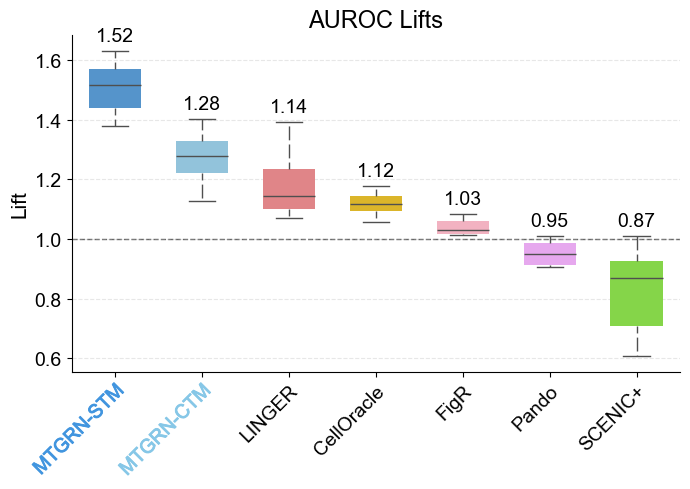

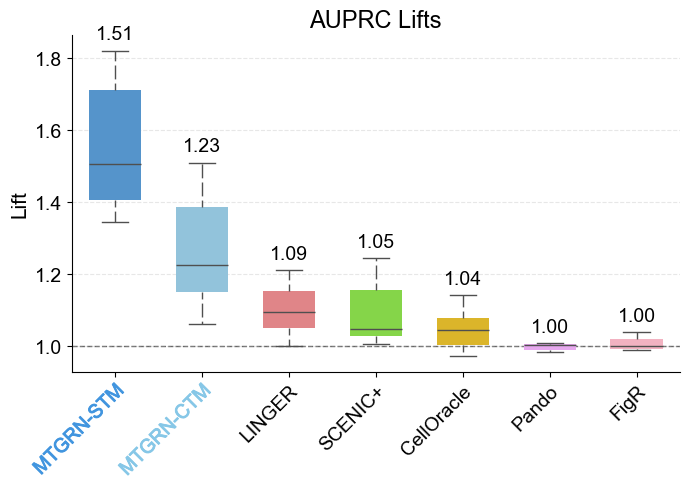

In [ ]:
lift_by_metric_boxplots = {}

for metric_col, rand_col, plot_title in [
    ("auroc", "rand_auroc", "AUROC Lifts"),
    ("auprc", "rand_auprc", "AUPRC Lifts"),
]:
    lift_by_method_fig, lift_by_method_ax = lift_by_method_boxplot(
        full_metric_df,
        metric_col=metric_col,
        rand_col=rand_col,
        method_color_dict=method_color_dict,
        title=plot_title,
        sample_rename_map=sample_rename_map,
    )
    
    lift_by_metric_boxplots[metric_col] = (lift_by_method_fig, lift_by_method_ax)
    
    lift_by_method_fig.savefig(
        lift_boxplot_dir / f"{metric_col}_lift_by_method_boxplot.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

### Rank Plots

In [ ]:
def metric_df_to_rank_df(
    full_metric_df,
    metric_col,
    experiment_col="sample_name",
    method_col="method_name",
    higher_is_better=True,
):
    metric_df = (
        full_metric_df
        [[experiment_col, method_col, metric_col]]
        .dropna()
        .copy()
    )

    metric_df = (
        metric_df
        .groupby([experiment_col, method_col], as_index=False)
        .agg(metric_value=(metric_col, "median"))
    )

    metric_df = metric_df.rename(
        columns={
            experiment_col: "experiment",
            method_col: "method",
        }
    )

    metric_df["rank"] = (
        metric_df
        .groupby("experiment")["metric_value"]
        .rank(
            method="min",
            ascending=not higher_is_better,
        )
        .astype(int)
    )

    all_ranks_df = metric_df.sort_values(["experiment", "rank"]).copy()

    rank_df = (
        all_ranks_df
        .groupby("method", as_index=False)
        .agg(
            avg_rank=("rank", "mean"),
            median_rank=("rank", "median"),
            mean_metric=("metric_value", "mean"),
        )
        .sort_values(["avg_rank", "median_rank"], ascending=True)
        .reset_index(drop=True)
    )

    return all_ranks_df, rank_df

def avg_rank_by_method_plot(
    avg_rank_df,
    method_color_dict,
    title,
    sample_rename_map=None,
    figsize=(7, 4),
    color_xticks=True,
):
    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = avg_rank_df.copy()
    order = plot_df["method"].tolist()

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=plot_df,
        x="method",
        y="avg_rank",
        order=order,
        hue="method",
        palette=method_color_dict,
        dodge=False,
        legend=False,
        ax=ax,
    )

    _style_xticklabels(ax, order, method_color_dict, sample_rename_map, color_xticks)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)
    ax.set_ylabel("Average Rank", fontsize=15)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=17)

    ax.set_ylim(0, max(plot_df["avg_rank"].max() + 0.5, 1.5))

    plt.tight_layout()
    return fig, ax

def avg_rank_by_method_lollipop_plot(
    avg_rank_df,
    method_color_dict,
    title,
    sample_rename_map=None,
    color_xticks=True,
    figsize=(7, 4),
):
    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = avg_rank_df.copy()
    order = plot_df["method"].tolist()

    y_positions = np.arange(len(plot_df))
    avg_ranks = plot_df["avg_rank"].to_numpy()
    colors = [method_color_dict.get(m, "gray") for m in plot_df["method"]]

    fig, ax = plt.subplots(figsize=figsize)
    
    max_rank = int(np.ceil(plot_df["avg_rank"].max()))
    left_edge = max(max_rank, 1.5)

    ax.hlines(
        y=y_positions,
        xmin=left_edge,
        xmax=avg_ranks,
        color=colors,
        linewidth=2,
        alpha=0.8,
        zorder=1,
    )

    ax.scatter(avg_ranks, y_positions, color=colors, s=200, zorder=2)

    ax.set_xlim(left_edge, 0.5)
    ax.set_xticks(np.arange(1, max_rank + 1))
    ax.set_yticks(y_positions)
    labels = [sample_rename_map.get(m, m) for m in order]
    ax.set_yticklabels(labels, fontsize=15)

    for tick, original in zip(ax.get_yticklabels(), order):
        if original in TFTG_MODEL_METHODS:
            tick.set_fontweight("bold")
            if color_xticks:
                tick.set_color(method_color_dict.get(original, "black"))
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")

    ax.invert_yaxis()

    ax.tick_params(axis="x", labelsize=15)
    ax.set_xlabel("Average Rank", fontsize=15)
    ax.set_ylabel("")
    ax.set_title(title, fontsize=17)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    return fig, ax


def experiment_by_method_rank_heatmap(
    all_ranks_df,
    rank_df,
    method_color_dict,
    title=None,
    sample_order=None,
    sample_rename_map=None,
    figsize=(10, 4),
    square_cells=True,
    color_xticks=True,
    show_values_in_boxes=True,
    random_baseline_series=None,
    random_baseline_label="Random",
):
    if sample_rename_map is None:
        sample_rename_map = {}

    if show_values_in_boxes:
        plot_value = "metric_value"
        cbar_label = "Metric Value"
        rounding_format = ".2f"
        cmap = "viridis"
    else:
        plot_value = "rank"
        cbar_label = "Rank"
        rounding_format = ".0f"
        cmap = "viridis_r"
    
    rank_heatmap_df = all_ranks_df.pivot(
        index="experiment",
        columns="method",
        values=plot_value,
    )

    method_order = rank_df["method"].tolist()

    if sample_order is None:
        sample_order = rank_heatmap_df.index.tolist()

    sample_order = [
        exp for exp in sample_order
        if exp in rank_heatmap_df.index
    ]

    rank_heatmap_df = rank_heatmap_df.reindex(
        index=sample_order,
        columns=method_order,
    )
    
    if random_baseline_series is not None:
        rank_heatmap_df[random_baseline_label] = (
            random_baseline_series.reindex(rank_heatmap_df.index)
        )
        method_order = method_order + [random_baseline_label]

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        rank_heatmap_df,
        annot=True,
        fmt=rounding_format,
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 14, "fontweight": "bold"},
        ax=ax,
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label("", fontsize=15)

    if square_cells:
        ax.set_aspect("equal")

    _style_xticklabels(ax, method_order, method_color_dict, sample_rename_map,
                   color_xticks, rotation=55)

    new_y_labels = []
    for tick in ax.get_yticklabels():
        original = tick.get_text()
        new = sample_rename_map.get(original, original)
        new_y_labels.append(new)

    ax.set_yticklabels(new_y_labels, rotation=0, fontsize=15)

    ax.set_title(title or "Method Rank by Test Set", fontsize=17)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    return fig, ax


def rank_by_method_boxplot(
    all_ranks_df,
    rank_df,
    method_color_dict,
    title=None,
    sample_rename_map=None,
    figsize=(7, 6),
    color_xticks=True,
    show_values_above_boxes=True,
    showfliers=False,
):
    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = all_ranks_df.copy()
    order = rank_df["method"].tolist()

    loosely_dashed = (5, (10, 3))

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x="method",
        y="rank",
        hue="method",
        order=order,
        width=0.6,
        palette=method_color_dict,
        whiskerprops={"linestyle": loosely_dashed, "linewidth": 1},
        boxprops={"linewidth": 0},
        capprops={"linewidth": 1},
        medianprops={"linewidth": 1},
        showfliers=showfliers,
        legend=False,
        ax=ax,
    )

    for i, method in enumerate(order):
        vals = plot_df.loc[plot_df["method"] == method, "rank"].dropna()
        if vals.empty:
            continue

        q1, q3 = vals.quantile([0.25, 0.75])
        top = vals[vals <= q3 + 1.5 * (q3 - q1)].max()

        if show_values_above_boxes:
            annotation = f"{vals.median():.1f}"
        else:
            annotation = str(i + 1)

        ax.text(i, top + 0.15, annotation, ha="center", va="bottom", fontsize=12)

    _style_xticklabels(
        ax, order, method_color_dict, sample_rename_map,
        color_xticks, rotation=45, fontsize=12,
    )

    ax.tick_params(axis="y", labelsize=14)
    ax.set_ylabel("Rank", fontsize=15)
    ax.set_xlabel("")
    ax.set_title(title or "Method Ranks by Test Set", fontsize=17)

    ax.set_ylim(0.5, plot_df["rank"].max() + 0.8)
    # ax.invert_yaxis()

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    return fig, ax


/tmp/ipykernel_2082756/3901177221.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


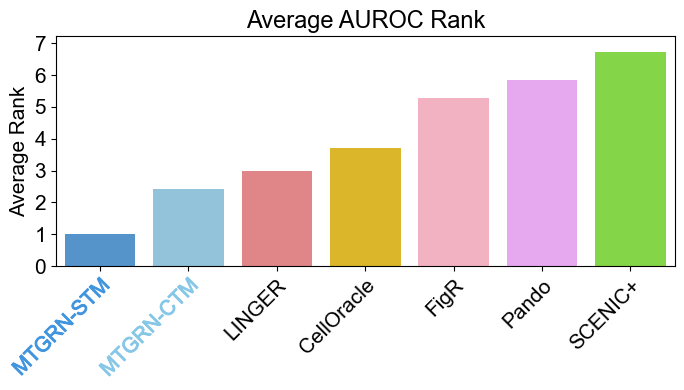

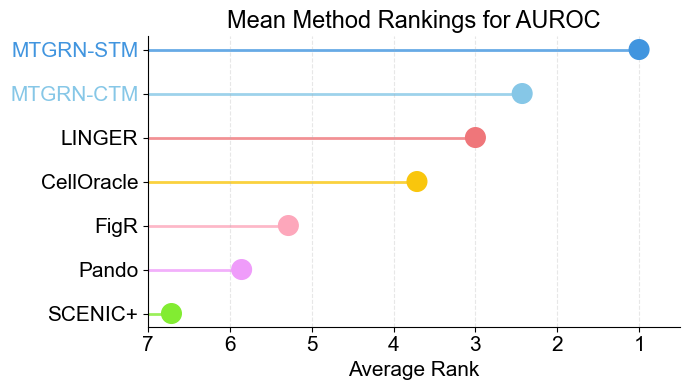

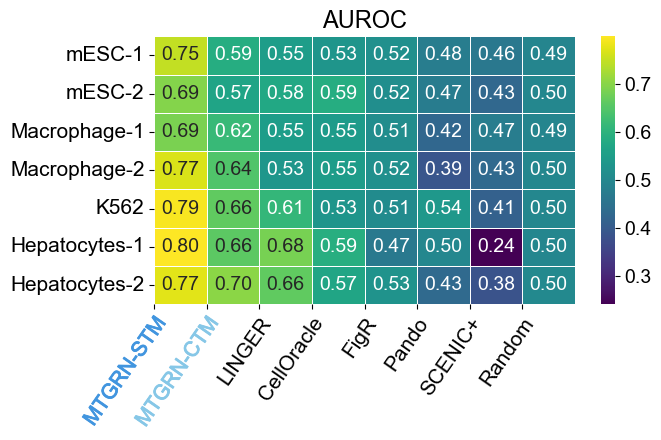

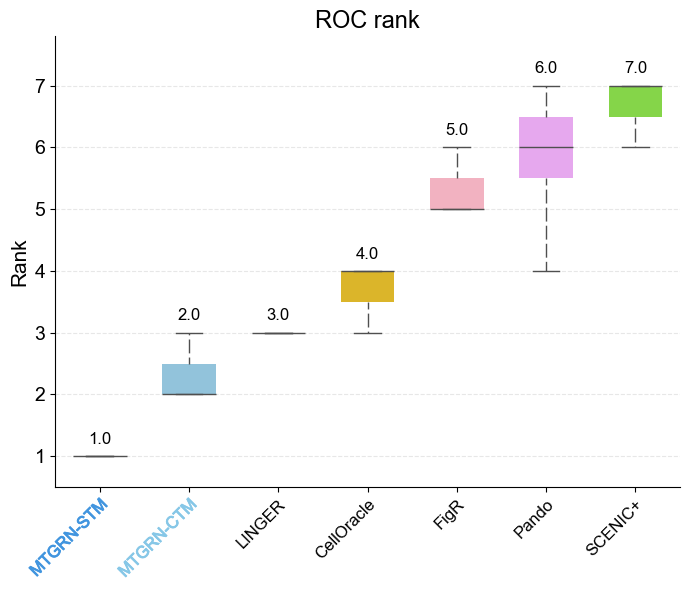

/tmp/ipykernel_2082756/3901177221.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


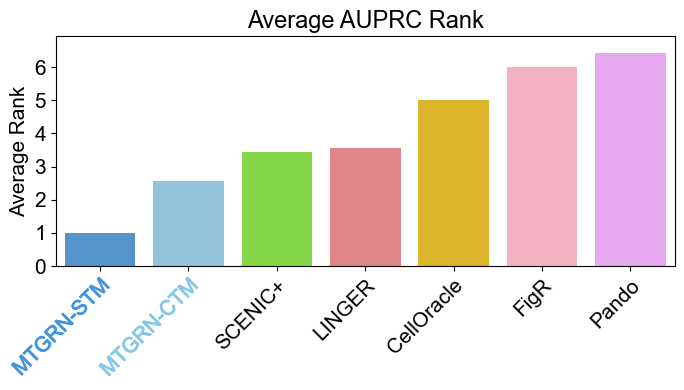

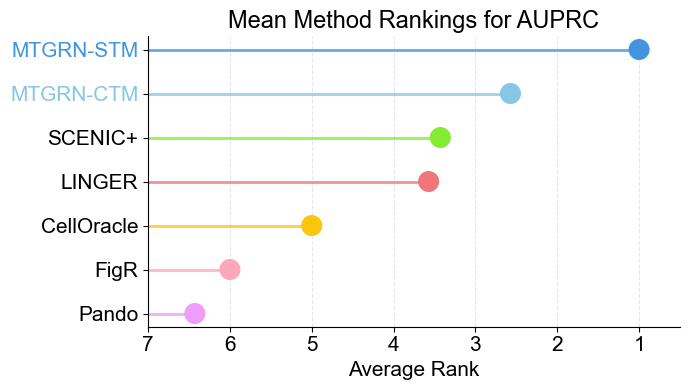

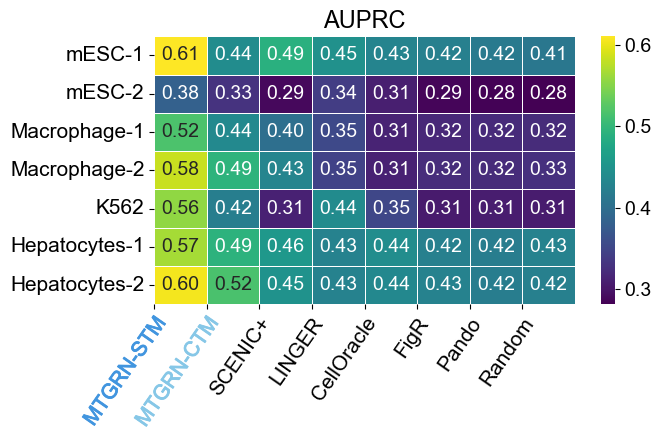

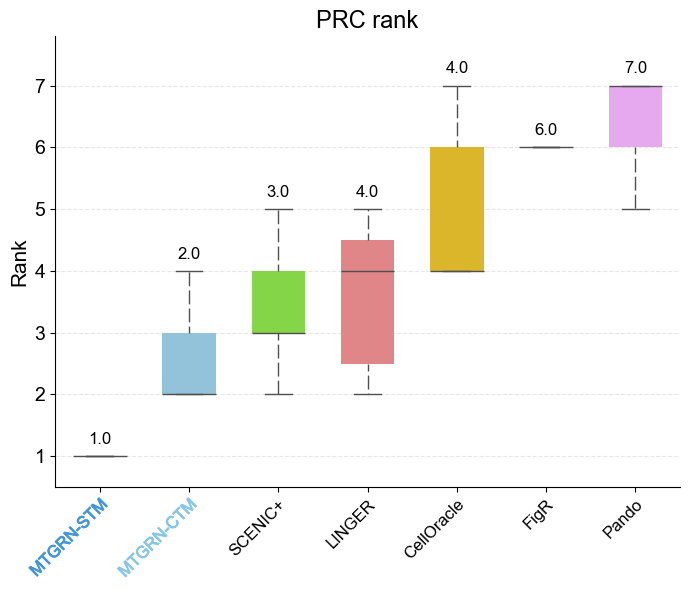

/tmp/ipykernel_2082756/3901177221.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


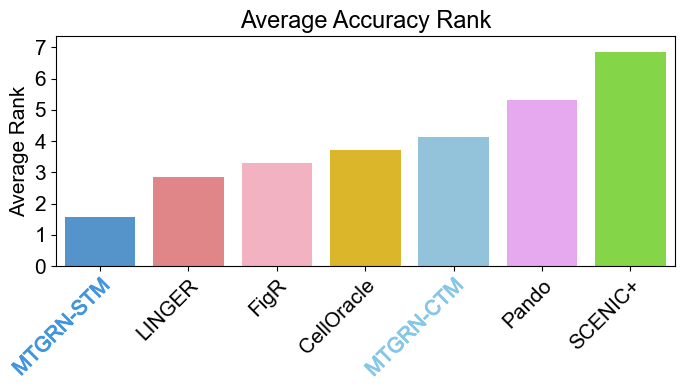

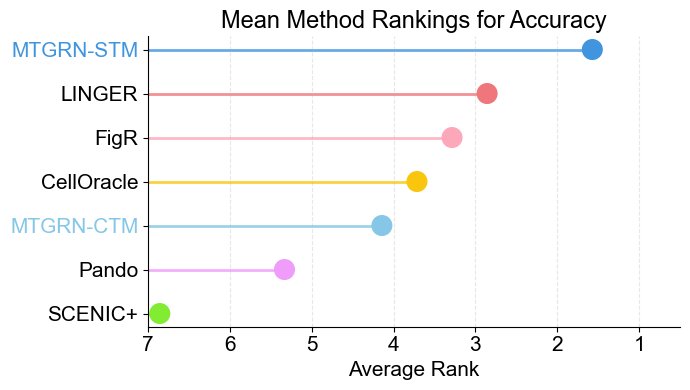

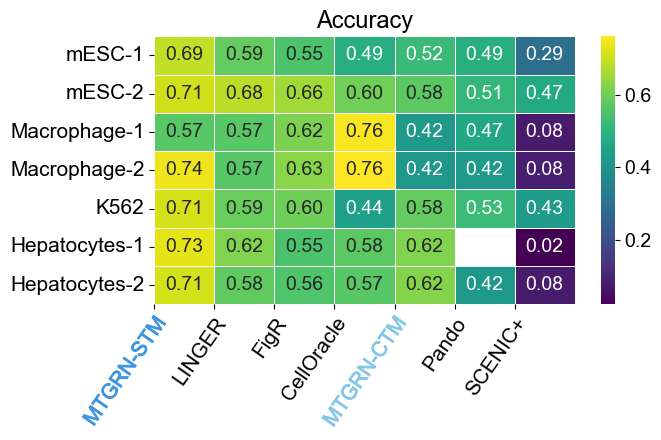

In [ ]:
metric_name_map = {
    "auroc": "AUROC",
    "auprc": "AUPRC",
    "accuracy": "Accuracy",
    "early_precision": "Early Precision",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
}

boxplot_metric_name_map = {
    "auroc": "ROC",
    "auprc": "PRC",
    "accuracy": "Accuracy",
    "early_precision": "Early Precision",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
}

metrics = [
    "auroc",
    "auprc",
    "accuracy",
    "early_precision",
    "precision",
    "recall",
    "f1",
]

RAND_COL_BY_METRIC = {
    "auroc": "rand_auroc",
    "auprc": "rand_auprc",
}

rank_plots = {}

for metric_col in metrics:
    metric_label = metric_name_map.get(
        metric_col,
        metric_col.replace("_", " ").title(),
    )
    
    boxplot_metric_label = boxplot_metric_name_map.get(
        metric_col,
        metric_col.replace("_", " ").title(),
    )

    all_ranks_df, rank_df = metric_df_to_rank_df(
        full_metric_df=full_metric_df,
        metric_col=metric_col,
        experiment_col="sample_name",
        method_col="method_name",
        higher_is_better=True,
    )

    safe_metric_name = metric_col.lower().replace(" ", "_")
    
    # Full method average-rank barplot
    full_avg_rank_fig, full_avg_rank_ax = avg_rank_by_method_plot(
        rank_df,
        method_color_dict=method_color_dict,
        title=f"Average {metric_label} Rank",
        sample_rename_map=sample_rename_map,
        figsize=(7, 4),
    )
    
    rank_plots["barplot"] = (full_avg_rank_fig, full_avg_rank_ax)

    full_avg_rank_fig.savefig(
        rank_bar_plot_dir / f"average_{safe_metric_name}_rank_all_methods.png",
        dpi=300,
        bbox_inches="tight",
    )
    
    # Full method average-rank lollipop plot
    full_avg_rank_fig, full_avg_rank_ax = avg_rank_by_method_lollipop_plot(
        rank_df,
        method_color_dict=method_color_dict,
        title=f"Mean Method Rankings for {metric_label}",
        sample_rename_map=sample_rename_map,
        figsize=(7, 4),
    )
    
    rank_plots["lollipop"] = (full_avg_rank_fig, full_avg_rank_ax)

    full_avg_rank_fig.savefig(
        rank_lollipop_plot_dir / f"average_{safe_metric_name}_rank_all_methods_lollipop.png",
        dpi=300,
        bbox_inches="tight",
    )
    
    rand_col = RAND_COL_BY_METRIC.get(metric_col)

    if rand_col is not None and rand_col in full_metric_df.columns:
        random_baseline = (
            full_metric_df
            .groupby("sample_name")[rand_col]
            .median()
        )
    else:
        random_baseline = None

    # Full method rank heatmap
    full_rank_heatmap_fig, full_rank_heatmap_ax = experiment_by_method_rank_heatmap(
        all_ranks_df,
        rank_df,
        method_color_dict=method_color_dict,
        sample_order=sample_order,
        sample_rename_map=sample_rename_map,
        title=f"{metric_label}",
        figsize=(7, 4.5),
        square_cells=False,
        color_xticks=True,
        show_values_in_boxes=True,
        random_baseline_series=random_baseline,
    )
    
    rank_plots["heatmap"] = (full_rank_heatmap_fig, full_rank_heatmap_ax)

    full_rank_heatmap_fig.savefig(
        rank_heatmap_plot_dir / f"{safe_metric_name}_rank_heatmap_all_methods.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
        
    full_rank_boxplot_fig, full_rank_boxplot_ax = rank_by_method_boxplot(
        all_ranks_df,
        rank_df,
        method_color_dict=method_color_dict,
        title=f"{boxplot_metric_label} rank",
        sample_rename_map=sample_rename_map,
        figsize=(7, 6),
        color_xticks=True,
        show_values_above_boxes=True,
        showfliers=False,
    )
    
    rank_plots["boxplot"] = (full_rank_boxplot_fig, full_rank_boxplot_ax)

    full_rank_boxplot_path = rank_boxplot_plot_dir / f"{safe_metric_name}_rank_boxplot_all_methods.png"
    full_rank_boxplot_fig.savefig(
        full_rank_boxplot_path,
        dpi=300,
        bbox_inches="tight",
    )
    
    plt.show()

---

## Evaluate TF-DNA Model Performance

In [ ]:
organism_code = "mm10"
cell_type = "mESC"
sample_name = "E7.5_rep1"
cell_type_cache_dir = DATA_DIR / f"{cell_type}_cache"

training_data = load_tf_dna_training_data(
    cell_type=cell_type,
    batch_size=512,
)

tf_embeddings_tensor = training_data["tf_embeddings_tensor"]
tf_mask_tensor = training_data["tf_mask_tensor"]

tf_dna_model = utils.load_tf_dna_model(
    tf_dna_model_path=config.tf_dna_model_checkpoints[cell_type],
    tf_embeddings_tensor=tf_embeddings_tensor,
    tf_mask_tensor=tf_mask_tensor,
    compile_model=False
)

In [ ]:
def create_tf_peak_index_to_name_mappings(training_data):
    #series to dict
    tf_name_to_idx_dict = training_data["tf_name_to_idx_df"].set_index("tf_name")["tf_idx"].to_dict()
    peak_name_to_idx_dict = training_data["peak_name_to_idx_df"].set_index("peak_id")["peak_idx"].to_dict()

    tf_idx_to_name = {idx: name for name, idx in tf_name_to_idx_dict.items()}
    peak_idx_to_name = {idx: name for name, idx in peak_name_to_idx_dict.items()}
    return tf_idx_to_name, peak_idx_to_name

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = tf_dna_model.model
model = model.to(device)

criterion = torch.nn.BCEWithLogitsLoss()
score_threshold = 0.5
pooling_mode = "lse"
pooling_temperature = 1.0

model.eval()

total_loss = 0.0
n_edges = 0

tf_indices_list = []
peak_indices_list = []
all_scores = []
all_labels = []
plot_data = {}

tf_idx_to_name, peak_idx_to_name = create_tf_peak_index_to_name_mappings(training_data)

test_loader = training_data["test_loader"]

# print(f"Evaluating on {dataset_split_type} set")
with torch.inference_mode():
    for batch in tqdm(test_loader, desc="Evaluating", ncols=100):
        
        tf_idx = batch["tf_idx"].long()
        peak_idx = batch["peak_idx"].long()
        labels = batch["label"]

        tf_embedding = tf_embeddings_tensor[tf_idx].to(device, non_blocking=True)
        tf_mask = tf_mask_tensor[tf_idx].to(device, non_blocking=True)

        peak_embedding = batch["peak_embedding"].float().to(device, non_blocking=True)

        binding_logits = model.forward(
            tf_embedding=tf_embedding,
            tf_mask=tf_mask,
            peak_embedding=peak_embedding,
        )

        scores = torch.sigmoid(binding_logits)

        all_scores.append(scores.detach().cpu().numpy().ravel())
        all_labels.append(labels.numpy().ravel())
        
        tf_indices_list.append(tf_idx.numpy().ravel())
        peak_indices_list.append(peak_idx.numpy().ravel())

all_tf_indices = np.concatenate(tf_indices_list)
all_peak_indices = np.concatenate(peak_indices_list)
all_scores_flat = np.concatenate(all_scores)
all_labels_flat = np.concatenate(all_labels)

tf_names = [tf_idx_to_name[idx] for idx in all_tf_indices]
peak_names = [peak_idx_to_name[idx] for idx in all_peak_indices]

prediction_df = pd.DataFrame({
    "TF": tf_names,
    "DNA": peak_names,
    "Score": all_scores_flat,
    "Label": all_labels_flat
})

In [ ]:
# Plot roc curve with scores and labels
accuracy = accuracy_score(all_labels_flat, all_scores_flat > score_threshold)
precision = precision_score(all_labels_flat, all_scores_flat > score_threshold)
recall = recall_score(all_labels_flat, all_scores_flat > score_threshold)
f1 = f1_score(all_labels_flat, all_scores_flat > score_threshold)
auprc = average_precision_score(all_labels_flat, all_scores_flat)
auroc = roc_auc_score(all_labels_flat, all_scores_flat)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Average Precision: {auprc:.4f}")
print(f"ROC AUC: {auroc:.4f}")

def tf_dna_binding_roc_plot(all_scores_flat, all_labels_flat, method_color_dict):
    tf_dna_roc_prc_fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_aspect("equal")

    rng = np.random.default_rng(42)
    random_curve_plotted = False

    fpr, tpr, _ = roc_curve(all_labels_flat, all_scores_flat)
    auroc = roc_auc_score(all_labels_flat, all_scores_flat)

    ax.plot(
        fpr,
        tpr,
        lw=3,
        color=method_color_dict[OWN_MODEL_METHOD],
        label=f"AUROC = {auroc:.3f}",
    )

    # Plot one shuffled/random baseline only
    if not random_curve_plotted:
        rand_scores = rng.permutation(all_scores_flat)
        rand_fpr, rand_tpr, _ = roc_curve(all_labels_flat, rand_scores)
        rand_auroc = roc_auc_score(all_labels_flat, rand_scores)

        ax.plot(
            rand_fpr,
            rand_tpr,
            color="black",
            linestyle="--",
            lw=2,
            alpha=0.6,
            zorder=1,
            label=f"Random = {rand_auroc:.3f}",
        )

        random_curve_plotted = True


    ax.set_title("AUROC", fontsize=30)
    ax.set_xlabel("False Positive Rate", fontsize=20)
    ax.set_ylabel("True Positive Rate", fontsize=20)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center",
        bbox_to_anchor=(0.5, -0.30),
        frameon=False,
        fontsize=20,
    )

    tf_dna_roc_prc_fig.subplots_adjust(
        left=0.10,
        right=0.72,
        bottom=0.10,
        top=0.90,
    )
    
    return tf_dna_roc_prc_fig, ax

def tf_dna_binding_prc_plot(all_scores_flat, all_labels_flat, method_color_dict):
    tf_dna_prc_fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_aspect("equal")

    rng = np.random.default_rng(42)

    precision, recall, _ = precision_recall_curve(all_labels_flat, all_scores_flat)
    auprc = average_precision_score(all_labels_flat, all_scores_flat)

    ax.plot(
        recall,
        precision,
        lw=3,
        color=method_color_dict[OWN_MODEL_METHOD],
        label=f"AUPRC = {auprc:.3f}",
    )

    # Plot one shuffled/random baseline
    rand_scores = rng.permutation(all_scores_flat)
    rand_precision, rand_recall, _ = precision_recall_curve(all_labels_flat, rand_scores)
    rand_auprc = average_precision_score(all_labels_flat, rand_scores)

    ax.plot(
        rand_recall,
        rand_precision,
        color="black",
        linestyle="--",
        lw=2,
        alpha=0.6,
        zorder=1,
        label=f"Random = {rand_auprc:.3f}",
    )

    ax.set_title("AUPRC", fontsize=30)
    ax.set_xlabel("Recall", fontsize=20)
    ax.set_ylabel("Precision", fontsize=20)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.tick_params(axis="both", labelsize=16)

    ax.legend(
        loc="center",
        bbox_to_anchor=(0.5, -0.35),
        frameon=False,
        fontsize=20,
    )

    tf_dna_prc_fig.subplots_adjust(
        left=0.10,
        right=0.72,
        bottom=0.25,
        top=0.90,
    )

    return tf_dna_prc_fig, ax

    
tf_dna_roc_fig, tf_dna_roc_ax = tf_dna_binding_roc_plot(
    all_scores_flat=all_scores_flat,
    all_labels_flat=all_labels_flat,
    method_color_dict=method_color_dict,
)

tf_dna_prc_fig, tf_dna_prc_ax = tf_dna_binding_prc_plot(
    all_scores_flat=all_scores_flat,
    all_labels_flat=all_labels_flat,
    method_color_dict=method_color_dict,
)

tf_dna_roc_fig_path = tf_dna_plots / f"roc_{organism_code}_tf_dna_vs_test_set.png"
tf_dna_prc_fig_path = tf_dna_plots / f"prc_{organism_code}_tf_dna_vs_test_set.png"

tf_dna_roc_fig.savefig(
    tf_dna_roc_fig_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
)

tf_dna_prc_fig.savefig(
    tf_dna_prc_fig_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
)

---

## Comparing GRN sizes 

In [ ]:
auprc_grns = load_auprc_grns_all_methods()
sample_list = list(auprc_grns.keys())

auroc_grns = {sample: load_generalizability_df(sample, sample) for sample in sample_list}
print("Loaded AUPRC and AUROC generalizability data for all samples.")
print(auroc_grns.keys())
print(auprc_grns.keys())

In [ ]:
def create_grn_size_summary_df(auprc_grns: dict) -> pd.DataFrame:
    summary_dict = {
        "sample_name": [],
        "method_name": [],
        "num_unique_tfs": [],
        "num_unique_tgs": [],
        "num_edges": [],
        "num_true_edges": [],
        "num_false_edges": [],
    }

    for sample_name, method_dict in auprc_grns.items():
        for method_name in method_dict.keys():
            full_test_set_grn_df = auprc_grns[sample_name][method_name]
            
            full_test_set_grn_df = full_test_set_grn_df[full_test_set_grn_df["Score"] != 0]
            
            num_unique_tfs = full_test_set_grn_df["Source"].nunique()
            num_unique_tgs = full_test_set_grn_df["Target"].nunique()
            num_edges = full_test_set_grn_df.shape[0]
            num_true_edges = full_test_set_grn_df["_in_gt"].sum()
            num_false_edges = num_edges - num_true_edges
            
            summary_dict["sample_name"].append(sample_name)
            summary_dict["method_name"].append(method_name)
            summary_dict["num_unique_tfs"].append(num_unique_tfs)
            summary_dict["num_unique_tgs"].append(num_unique_tgs)
            summary_dict["num_edges"].append(num_edges)
            summary_dict["num_true_edges"].append(num_true_edges)
            summary_dict["num_false_edges"].append(num_false_edges)
        
    summary_df = pd.DataFrame(summary_dict)
    return summary_df

auprc_summary_df = create_grn_size_summary_df(auprc_grns)
auroc_summary_df = create_grn_size_summary_df(auroc_grns)

### Network size box and whisker plots

In [ ]:
def plot_grn_size_boxplot(summary_df, method_color_dict, variable_name="num_edges", title_suffix=None):
    assert variable_name in summary_df.columns, f"{variable_name} not found in summary_df columns"

    plot_df = summary_df.copy()

    # Clean method names for matching against method_color_dict
    plot_df["method_name_clean"] = (
        plot_df["method_name"]
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    # Also clean method_color_dict keys, in case any of them contain newlines
    clean_color_dict = {
        method.replace("\n", " ").strip(): color
        for method, color in method_color_dict.items()
    }

    method_order = [
        method for method in clean_color_dict.keys()
        if method in plot_df["method_name_clean"].unique()
    ]

    def format_method_label(method):
        return (
            method
            .replace(" (own test set)", "\n(own test set)")
            .replace(" (cross test set)", "\n(cross test set)")
            .replace(" (cross-trained)", "\n(cross-trained)")
        )

    fig, ax = plt.subplots(figsize=(5, 4))

    sns.boxplot(
        data=plot_df,
        x="method_name_clean",
        y=variable_name,
        hue="method_name_clean",
        order=method_order,
        hue_order=method_order,
        palette=clean_color_dict,
        showfliers=False,
        width=0.5,
        ax=ax,
        legend=False,
    )

    ax.set_xticks(range(len(method_order)))
    ax.set_xticklabels(
        [format_method_label(method) for method in method_order],
        rotation=45,
        ha="right",
        fontsize=12,
        rotation_mode="anchor"
    )

    ax.tick_params(axis="y", labelsize=12)
    ax.set_ylabel(variable_name.replace("_", " ").title(), fontsize=14)
    ax.set_xlabel("")
    ax.set_title(
        f"{variable_name.replace('_', ' ').title()} by Method Across Samples" + (f"{title_suffix}" if title_suffix else ""),
        fontsize=16,
    )

    fig.tight_layout()

    return fig, ax

# Plot GRN size boxplots for AUPRC GRNs
auprc_tf_by_method_boxplot_fig, auprc_tf_by_method_boxplot_ax = plot_grn_size_boxplot(auprc_summary_df, method_color_dict, variable_name="num_unique_tfs", title_suffix="\n(AUPRC GRNs)")
auprc_tg_by_method_boxplot_fig, auprc_tg_by_method_boxplot_ax = plot_grn_size_boxplot(auprc_summary_df, method_color_dict, variable_name="num_unique_tgs", title_suffix="\n(AUPRC GRNs)")
auprc_edge_by_method_boxplot_fig, auprc_edge_by_method_boxplot_ax = plot_grn_size_boxplot(auprc_summary_df, method_color_dict, variable_name="num_edges", title_suffix="\n(AUPRC GRNs)")

auprc_tf_by_method_boxplot_fig.savefig(grn_sizes_by_method_dir / "num_tfs_by_method_boxplot_auprc.png", dpi=300, bbox_inches="tight")
auprc_tg_by_method_boxplot_fig.savefig(grn_sizes_by_method_dir / "num_tgs_by_method_boxplot_auprc.png", dpi=300, bbox_inches="tight")
auprc_edge_by_method_boxplot_fig.savefig(grn_sizes_by_method_dir / "num_edges_by_method_boxplot_auprc.png", dpi=300, bbox_inches="tight")

# Plot GRN size boxplots for AUROC GRNs
auroc_tf_by_method_boxplot_fig, auroc_tf_by_method_boxplot_ax = plot_grn_size_boxplot(auroc_summary_df, method_color_dict, variable_name="num_unique_tfs", title_suffix="\n(AUROC GRNs)")
auroc_tg_by_method_boxplot_fig, auroc_tg_by_method_boxplot_ax = plot_grn_size_boxplot(auroc_summary_df, method_color_dict, variable_name="num_unique_tgs", title_suffix="\n(AUROC GRNs)")
auroc_edge_by_method_boxplot_fig, auroc_edge_by_method_boxplot_ax = plot_grn_size_boxplot(auroc_summary_df, method_color_dict, variable_name="num_edges", title_suffix="\n(AUROC GRNs)")

auroc_tf_by_method_boxplot_fig.savefig(grn_sizes_by_method_dir / "num_tfs_by_method_boxplot_auroc.png", dpi=300, bbox_inches="tight")
auroc_tg_by_method_boxplot_fig.savefig(grn_sizes_by_method_dir / "num_tgs_by_method_boxplot_auroc.png", dpi=300, bbox_inches="tight")
auroc_edge_by_method_boxplot_fig.savefig(grn_sizes_by_method_dir / "num_edges_by_method_boxplot_auroc.png", dpi=300, bbox_inches="tight")

### Network size jitter plots

In [ ]:
def plot_grn_size_jitter(
    summary_df,
    method_color_dict,
    variable_name="num_edges",
    sample_col="sample_name",
    point_size_col="num_unique_tfs",
    sample_order=None,
    sample_rename_map=None,
    title_suffix=None,
    figsize=(10, 5),
    jitter=0.12,
    min_point_size=50,
    max_point_size=250,
    random_seed=42,
):
    """
    Plot GRN sizes across samples.

    Point color represents the GRN inference method.
    Point size represents the value in point_size_col, which defaults
    to the number of unique TFs.
    """
    required_columns = {
        variable_name,
        sample_col,
        "method_name",
    }
    missing_columns = required_columns.difference(summary_df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = summary_df.copy()

    # Clean method names
    plot_df["method_name_clean"] = (
        plot_df["method_name"]
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    # Clean method-color dictionary keys in the same way
    clean_color_dict = {
        " ".join(str(method).replace("\n", " ").split()): color
        for method, color in method_color_dict.items()
    }

    # Retain dictionary ordering
    available_methods = set(
        plot_df["method_name_clean"].dropna().unique()
    )
    method_order = [
        method
        for method in clean_color_dict
        if method in available_methods
    ]

    if sample_order is None:
        sample_order = (
            plot_df[sample_col]
            .dropna()
            .drop_duplicates()
            .tolist()
        )

    # Keep only requested samples and methods with assigned colors
    plot_df = plot_df[
        plot_df[sample_col].isin(sample_order)
        & plot_df["method_name_clean"].isin(method_order)
    ].copy()

    if plot_df.empty:
        raise ValueError(
            "No observations remain after filtering by sample and method."
        )

    sample_to_x = {
        sample: position
        for position, sample in enumerate(sample_order)
    }

    plot_df["x_position"] = plot_df[sample_col].map(sample_to_x)

    # Add deterministic horizontal jitter
    rng = np.random.default_rng(random_seed)
    plot_df["x_jittered"] = (
        plot_df["x_position"]
        + rng.uniform(
            -jitter,
            jitter,
            size=len(plot_df),
        )
    )

    # Scale point area by number of unique TFs
    use_size_mapping = (
        point_size_col is not None
        and point_size_col in plot_df.columns
    )

    if use_size_mapping:
        plot_df[point_size_col] = (
            plot_df[point_size_col]
            .astype(float)
        )

        size_min = plot_df[point_size_col].min()
        size_max = plot_df[point_size_col].max()

        def scale_point_size(value):
            if size_max == size_min:
                return (min_point_size + max_point_size) / 2

            return (
                min_point_size
                + (value - size_min)
                / (size_max - size_min)
                * (max_point_size - min_point_size)
            )

        plot_df["point_size"] = (
            plot_df[point_size_col]
            .apply(scale_point_size)
        )

    else:
        size_min = None
        size_max = None
        plot_df["point_size"] = 90

    fig, (ax, legend_ax) = plt.subplots(
        ncols=2,
        figsize=figsize,
        gridspec_kw={
            "width_ratios": [3.2, 1.8],
            "wspace": 0.05,
        },
    )

    legend_ax.axis("off")

    # Plot methods separately to construct the color legend
    for method in method_order:
        method_df = plot_df[
            plot_df["method_name_clean"] == method
        ]

        if method_df.empty:
            continue

        ax.scatter(
            method_df["x_jittered"],
            method_df[variable_name],
            s=method_df["point_size"],
            color=clean_color_dict[method],
            label=method,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.7,
            zorder=3,
        )

    # Configure sample labels
    formatted_sample_labels = [
        sample_rename_map.get(sample, sample)
        for sample in sample_order
    ]

    ax.set_xticks(range(len(sample_order)))
    ax.set_xticklabels(
        formatted_sample_labels,
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=12,
    )

    y_label_map = {
        "num_edges": "Number of Edges",
        "num_unique_tfs": "Number of Unique TFs",
        "num_unique_tgs": "Number of Unique TGs",
    }

    title_map = {
        "num_edges": "GRN Edge Counts",
        "num_unique_tfs": "Unique TF Counts",
        "num_unique_tgs": "Unique TG Counts",
    }

    y_label = y_label_map.get(
        variable_name,
        variable_name.replace("_", " ").title(),
    )
    plot_title = title_map.get(
        variable_name,
        variable_name.replace("_", " ").title(),
    )

    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_title(
        plot_title + (title_suffix or ""),
        fontsize=16,
    )

    ax.tick_params(axis="y", labelsize=12)

    # Format large y-axis values as 50K, 100K, 1M, etc.
    def format_large_number(value, position):
        if abs(value) >= 1_000_000:
            return f"{value / 1_000_000:g}M"

        if abs(value) >= 1_000:
            return f"{value / 1_000:g}K"

        return f"{value:g}"

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(format_large_number)
    )
    
    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.8,
        alpha=0.25,
        zorder=0,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Create method legend handles explicitly
    method_handles = [
        Line2D(
            [],
            [],
            linestyle="none",
            marker="o",
            markersize=8,
            markerfacecolor=clean_color_dict[method],
            markeredgecolor="white",
            markeredgewidth=0.7,
            label=method,
        )
        for method in method_order
    ]

    method_legend = legend_ax.legend(
        handles=method_handles,
        title="Method",
        loc="upper left",
        bbox_to_anchor=(0.0, 1.05),
        borderaxespad=0,
        frameon=False,
        facecolor="white",
        fontsize=11,
        title_fontsize=12,
    )

    legend_ax.add_artist(method_legend)

    # TF-size legend
    if use_size_mapping:
        desired_legend_values = [50, 100, 150, 200]

        tf_legend_values = [
            value
            for value in desired_legend_values
            if size_min <= value <= size_max
        ]

        # Use data-derived values if fixed values are outside the data range
        if not tf_legend_values:
            tf_legend_values = (
                np.linspace(size_min, size_max, 4)
                .round()
                .astype(int)
            )
            tf_legend_values = np.unique(
                tf_legend_values
            ).tolist()

        size_handles = [
            Line2D(
                [],
                [],
                linestyle="none",
                marker="o",
                markersize=np.sqrt(
                    scale_point_size(value)
                ),
                markerfacecolor="dimgray",
                markeredgecolor="white",
                markeredgewidth=0.7,
                label=f"{value:,}",
            )
            for value in tf_legend_values
        ]

        legend_ax.legend(
            handles=size_handles,
            title="TFs",
            loc="upper left",
            bbox_to_anchor=(0.0, 0.40),
            borderaxespad=0,
            frameon=False,
            facecolor="white",
            fontsize=11,
            title_fontsize=12,
            handletextpad=0.8,
            labelspacing=0.8,
        )
        
    ax.set_xlim(-0.4, len(sample_order) - 0.5)

    fig.subplots_adjust(
        left=0.10,
        right=0.96,
        top=0.86,
        bottom=0.27,
    )
    
    return fig, ax

sample_order = list(sample_rename_map.keys())

auprc_edge_jitter_fig, auprc_edge_jitter_ax = plot_grn_size_jitter(
    summary_df=auprc_summary_df,
    method_color_dict=method_color_dict,
    variable_name="num_edges",
    sample_col="sample_name",
    point_size_col="num_unique_tfs",
    sample_order=sample_order,
    sample_rename_map=sample_rename_map,
    title_suffix="\n(AUPRC GRNs)",
    figsize=(10, 5),
)

auprc_edge_jitter_fig.savefig(
    grn_sizes_by_method_dir / "num_edges_jitter_auprc.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

auroc_edge_jitter_fig, auroc_edge_jitter_ax = plot_grn_size_jitter(
    summary_df=auroc_summary_df,
    method_color_dict=method_color_dict,
    variable_name="num_edges",
    sample_col="sample_name",
    point_size_col="num_unique_tfs",
    sample_order=sample_order,
    sample_rename_map=sample_rename_map,
    title_suffix="\n(AUROC GRNs)",
    figsize=(10, 5),
)

auroc_edge_jitter_fig.savefig(
    grn_sizes_by_method_dir / "num_edges_jitter_auroc.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### Percent of edge combination box and whisker plots

In [ ]:
def add_percent_edges_vs_own(
    summary_df,
    own_method=OWN_MODEL_METHOD,
    edge_col="num_edges",
    percent_col="percent_of_total_edge_combinations",
):
    plot_df = summary_df.copy()

    own_edge_df = (
        plot_df[plot_df["method_name"] == own_method]
        [["sample_name", edge_col]]
        .drop_duplicates(subset=["sample_name"])
        .rename(columns={edge_col: "own_test_set_edges"})
    )

    plot_df = plot_df.merge(
        own_edge_df,
        on="sample_name",
        how="left",
        validate="many_to_one",
    )

    missing_samples = plot_df.loc[
        plot_df["own_test_set_edges"].isna(),
        "sample_name"
    ].unique()

    if len(missing_samples) > 0:
        raise ValueError(
            f"Missing own-test-set edge counts for samples: {missing_samples}"
        )

    plot_df[percent_col] = (
        100 * plot_df[edge_col] / plot_df["own_test_set_edges"]
    )
    
    # plot_df = plot_df[
    #     (plot_df["method_name"] != own_method) & 
    #     (plot_df["method_name"] != CROSS_MODEL_METHOD)
    #     ].copy()

    return plot_df


summary_percent_df = add_percent_edges_vs_own(
    summary_df,
    edge_col="num_edges",
    percent_col="percent_edge_combinations\n",
)

percent_edges_boxplot_fig, percent_edges_boxplot_ax = plot_grn_size_boxplot(
    summary_percent_df,
    method_color_dict,
    variable_name="percent_edge_combinations\n",
)

percent_edges_boxplot_fig.savefig(
    grn_sizes_by_method_dir / "percent_edge_combinations_test_set_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)

---

## Stability

In [35]:
models_to_plot = [
    "E7.5_rep1",
    "E8.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
    "hepatocytes_1",
    "hepatocytes_3",
]

stability_result_dir = RESULT_DIR / "stability_evaluation"

def load_tether_stability_results(stability_result_dir, models_to_plot):
    stability_labeled_score_dfs = {}
    stability_metric_dfs = []

    for sample_name in models_to_plot:
        stability_labeled_score_dfs[sample_name] = {}
        for subsample_num in range(0, 10):
            prediction_save_file = stability_result_dir / "labeled_grns" / f"{sample_name}_stability_{subsample_num}_grn.csv"
            metric_save_file = stability_result_dir / "comparison_metric_files" / f"{sample_name}_stability_{subsample_num}_metrics.csv"
            
            if prediction_save_file.exists():
                labeled_score_df = pd.read_csv(prediction_save_file)
                stability_labeled_score_dfs[sample_name][subsample_num] = labeled_score_df
            else:
                logging.debug(f"Missing prediction file: {prediction_save_file}")
            
            if metric_save_file.exists():
                metric_df = pd.read_csv(metric_save_file)
                stability_metric_dfs.append(metric_df)
            else:
                logging.debug(f"Missing metric file: {metric_save_file}")

    if stability_metric_dfs:
        combined_stability_metric_df = pd.concat(stability_metric_dfs, ignore_index=True)
    else:
        combined_stability_metric_df = pd.DataFrame()
        logging.debug("No stability metric files found.")

    return stability_labeled_score_dfs, combined_stability_metric_df

stability_labeled_score_dfs, combined_stability_metric_df = load_tether_stability_results(stability_result_dir, models_to_plot)

In [36]:
def calculate_jaccard_index(df_x, df_y):
    df_x_sorted = df_x.sort_values(by="Score", ascending=False)
    df_y_sorted = df_y.sort_values(by="Score", ascending=False)

    df_x_top_10_pct = df_x_sorted.head(int(0.1 * len(df_x_sorted)))
    df_y_top_10_pct = df_y_sorted.head(int(0.1 * len(df_y_sorted)))
    
    edges_x = set(zip(df_x_top_10_pct["Source"], df_x_top_10_pct["Target"]))
    edges_y = set(zip(df_y_top_10_pct["Source"], df_y_top_10_pct["Target"]))
    
    union = edges_x | edges_y
    intersection = edges_x & edges_y
    jaccard_index = len(intersection) / len(union) if union else 0.0
    
    return jaccard_index

In [37]:
# Calculate the pairwise Jaccard indices for the top 10% of edges across subsamples for each sample
sample_jaccard_indices = {}
for sample_name, score_by_subsample in stability_labeled_score_dfs.items():
    sample_jaccard_indices[sample_name] = []
    available_subsamples = sorted(score_by_subsample.keys())

    for i, subsample_num_x in enumerate(available_subsamples):
        for subsample_num_y in available_subsamples[i + 1:]:
            df_x = score_by_subsample[subsample_num_x]
            df_y = score_by_subsample[subsample_num_y]
            
            random_df_x = df_x.copy()
            random_df_y = df_y.copy()
            
            random_df_x["Score"] = random_df_x["Score"].sample(frac=1, random_state=42).reset_index(drop=True)
            random_df_y["Score"] = random_df_y["Score"].sample(frac=1, random_state=42).reset_index(drop=True)

            jaccard_index = calculate_jaccard_index(df_x, df_y)
            random_jaccard_index = calculate_jaccard_index(random_df_x, random_df_y)
            
            sample_jaccard_indices[sample_name].append((subsample_num_x, subsample_num_y, jaccard_index, random_jaccard_index))

# Plot boxplots of Jaccard indices for each sample
jaccard_plot_data = []
for sample_name, jaccard_list in sample_jaccard_indices.items():
    for subsample_num_x, subsample_num_y, jaccard_index, random_jaccard_index in jaccard_list:
        jaccard_plot_data.append({
            "method_name": OWN_MODEL_METHOD,
            "sample_name": sample_name,
            "subsample_pair": f"{subsample_num_x}-{subsample_num_y}",
            "jaccard_index": jaccard_index,
            "random_jaccard_index": random_jaccard_index
        })
    
tether_jaccard_plot_df = pd.DataFrame(jaccard_plot_data)

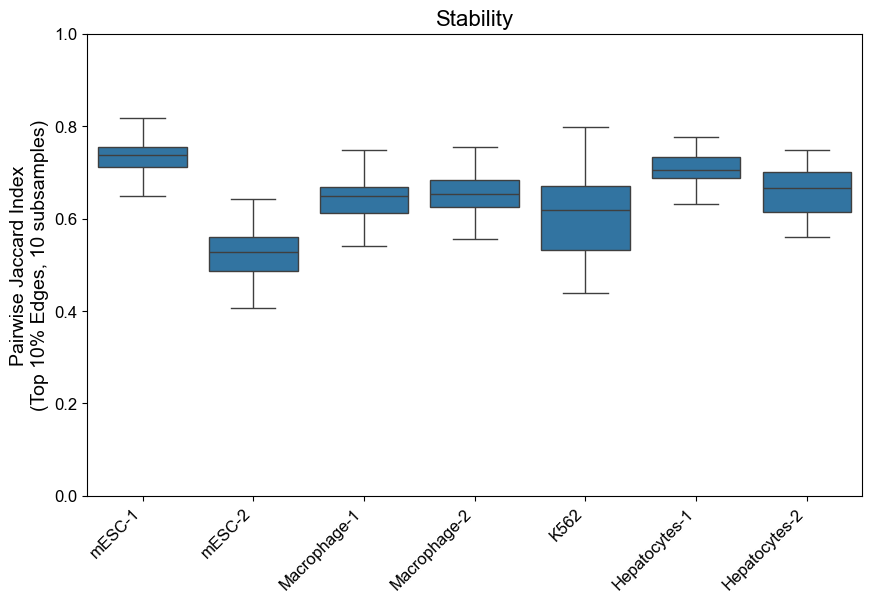

In [38]:
def plot_method_stability_by_sample_boxplot(jaccard_plot_df, sample_order, sample_rename_map):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title("Stability", fontsize=16)
    sns.boxplot(
        data=jaccard_plot_df,
        x="sample_name",
        y="jaccard_index",
        showfliers=False,
        ax=ax,
    )

    ax.set_xticks(range(len(sample_order)))
    ax.set_xticklabels(
        [sample_rename_map.get(sample, sample) for sample in sample_order],
        rotation=45, ha="right", fontsize=12,
    )

    ax.tick_params(axis="y", labelsize=12)
    ax.set_ylabel("Pairwise Jaccard Index\n(Top 10% Edges, 10 subsamples)", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylim(0, 1)

    return fig, ax

stability_boxplot_fig, stability_boxplot_ax = plot_method_stability_by_sample_boxplot(tether_jaccard_plot_df, sample_order, sample_rename_map)
stability_boxplot_fig.show()

In [39]:
tether_jaccard_plot_df.groupby("sample_name")["jaccard_index"].median()

sample_name
E7.5_rep1        0.738035
E8.5_rep1        0.527315
buffer_1         0.648265
buffer_2         0.652605
hepatocytes_1    0.705968
hepatocytes_3    0.667141
sample_1         0.617728
Name: jaccard_index, dtype: float64

### Other Inference Method Stability

In [47]:
other_method_stability_grn_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.GRN_BENCHMARKING.MOELLER/multiGRNtools/stability_formatted_GRNs")

def label_df(df, gt_tfs, gt_tgs, gt_pairs):
    df = df.copy()
    
    df = df[
        (df["Source"].str.upper().isin(gt_tfs)) &
        (df["Target"].str.upper().isin(gt_tgs))
        ]
    
    df["_in_gt"] = (
        (df["Source"].str.upper() + "\t" + df["Target"].str.upper()).isin(gt_pairs)
    )
    return df

other_method_stability_score_dfs = {}
for method_name_dir in other_method_stability_grn_dir.iterdir():
    if method_name_dir.is_dir():
        method_name = method_name_dir.name
        logging.info(f"Processing stability GRNs for method: {method_name}")
        
        other_method_stability_score_dfs[method_name] = {}
        
        for sample_name in models_to_plot:
            logging.info(f"    - Sample: {sample_name}")
            n_subsamples = 0
            cell_type = org_dict[sample_name][1]
            
            sample_dir = method_name_dir / f"{cell_type}/{sample_name}"
            
            # Load the merged ground truth
            cell_type_cache_dir = DATA_DIR / f"{cell_type}_cache"
            merged_ground_truth_df = pd.read_parquet(cell_type_cache_dir / f"{cell_type}_merged_ground_truth.parquet")

            gt_tfs = set(merged_ground_truth_df["Source"].str.upper().unique())
            gt_tgs = set(merged_ground_truth_df["Target"].str.upper().unique())
            gt_pairs = (merged_ground_truth_df["Source"].str.upper() + "\t" + merged_ground_truth_df["Target"].str.upper()).drop_duplicates()
                
            if sample_dir.exists() and sample_dir.is_dir():
                
                other_method_stability_score_dfs[method_name][sample_name] = {}
                for subsample_num in range(0, 10):
                    prediction_save_file = sample_dir / f"subsample_{subsample_num}.tsv"
                    
                    if prediction_save_file.exists():
                        labeled_score_df = label_df(pd.read_csv(prediction_save_file, sep="\t"), gt_tfs, gt_tgs, gt_pairs)
                        other_method_stability_score_dfs[method_name][sample_name][subsample_num] = labeled_score_df
                        
                        n_subsamples += 1
                    else:
                        logging.debug(f"Missing prediction file: {prediction_save_file}")
        logging.info(f"  - Num Subsamples: {n_subsamples}")

print()
other_method_jaccard_indices = {}
for method_name, subsample_dict in other_method_stability_score_dfs.items():
    print(f"{method_name}")
    
    
    for sample_name, subsample_dict in subsample_dict.items():
        print(f"  {sample_name}")
        
        
        cell_type = org_dict[sample_name][1]

        for subsample_num, df in subsample_dict.items():
            print(f"    Subsample {subsample_num}, Edges: {len(df):,} (True: {df['_in_gt'].sum():,}, False: {len(df) - df['_in_gt'].sum():,})")

# Calculate the pairwise Jaccard indices for the top 10% of edges across subsamples for each sample
for method_name, subsample_dict in other_method_stability_score_dfs.items():
    for sample_name, score_by_subsample in subsample_dict.items():
        other_method_jaccard_indices[method_name] = {}
        other_method_jaccard_indices[method_name][sample_name] = []
        available_subsamples = sorted(score_by_subsample.keys())

        for i, subsample_num_x in enumerate(available_subsamples):
            for subsample_num_y in available_subsamples[i + 1:]:
                if subsample_num_x != subsample_num_y:
                    df_x = score_by_subsample[subsample_num_x]
                    df_y = score_by_subsample[subsample_num_y]
                    
                    random_df_x = df_x.copy()
                    random_df_y = df_y.copy()
                    
                    random_df_x["Score"] = random_df_x["Score"].sample(frac=1, random_state=42).reset_index(drop=True)
                    random_df_y["Score"] = random_df_y["Score"].sample(frac=1, random_state=42).reset_index(drop=True)

                    jaccard_index = calculate_jaccard_index(df_x, df_y)
                    random_jaccard_index = calculate_jaccard_index(random_df_x, random_df_y)
                    
                    other_method_jaccard_indices[method_name][sample_name].append((subsample_num_x, subsample_num_y, jaccard_index, random_jaccard_index))

Processing stability GRNs for method: SCENIC_PLUS
Processing stability GRNs for method: FigR
Processing stability GRNs for method: CellOracle
Processing stability GRNs for method: LINGER
Processing stability GRNs for method: Pando
Processing stability GRNs for method: .staging

SCENIC_PLUS
  E7.5_rep1
    Subsample 0, Edges: 13,863 (True: 8,700, False: 5,163)
    Subsample 1, Edges: 13,907 (True: 8,353, False: 5,554)
    Subsample 2, Edges: 12,012 (True: 7,441, False: 4,571)
    Subsample 3, Edges: 13,323 (True: 8,254, False: 5,069)
    Subsample 4, Edges: 12,503 (True: 7,586, False: 4,917)
    Subsample 5, Edges: 14,461 (True: 8,822, False: 5,639)
    Subsample 6, Edges: 14,192 (True: 9,238, False: 4,954)
    Subsample 7, Edges: 12,591 (True: 7,504, False: 5,087)
    Subsample 8, Edges: 15,682 (True: 9,971, False: 5,711)
    Subsample 9, Edges: 11,070 (True: 7,494, False: 3,576)
  E8.5_rep1
    Subsample 0, Edges: 7,775 (True: 4,187, False: 3,588)
    Subsample 1, Edges: 5,590 (True: 

In [41]:
# Plot boxplots of Jaccard indices for each sample
other_method_jaccard_plot_data = []
for method_name, sample_dict in other_method_jaccard_indices.items():
    for sample_name, jaccard_list in sample_dict.items():
        for subsample_num_x, subsample_num_y, jaccard_index, random_jaccard_index in jaccard_list:
            other_method_jaccard_plot_data.append({
                "method_name": method_name,
                "sample_name": sample_name,
                "subsample_pair": f"{subsample_num_x}-{subsample_num_y}",
                "jaccard_index": jaccard_index,
                "random_jaccard_index": random_jaccard_index
            })

other_method_jaccard_plot_df = pd.DataFrame(other_method_jaccard_plot_data)

In [46]:
other_method_jaccard_plot_df

""


In [42]:
jaccard_plot_df = pd.concat([tether_jaccard_plot_df, other_method_jaccard_plot_df], ignore_index=False)

In [43]:
jaccard_plot_df.groupby("method_name").median("jaccard_index")

,jaccard_index,random_jaccard_index
method_name,,
TF-TG Model (own test set),0.653481,0.653481


In [44]:
jaccard_plot_df.to_csv(stability_result_dir / "stability_jaccard_indices_by_method.csv", index=False)

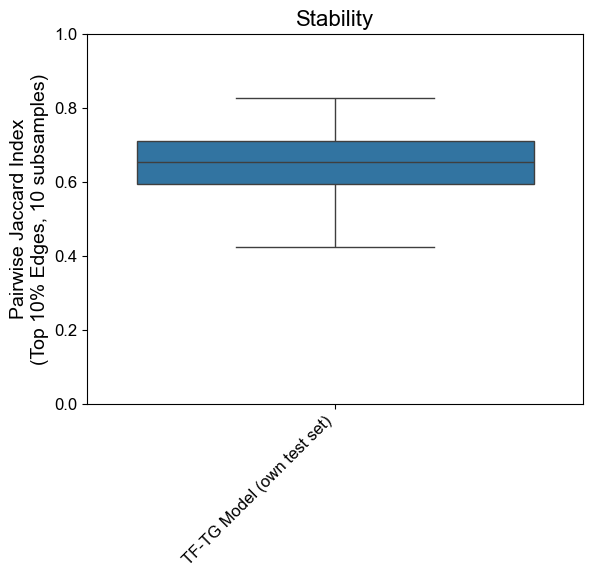

In [45]:
plt.title("Stability", fontsize=16)
sns.boxplot(
    data=jaccard_plot_df, 
    x="method_name", 
    y="jaccard_index", 
    showfliers=False,
    hue="method_name",
    )

# Rename using sample_rename_map
# plt.xticks(ticks=range(len(sample_order)), 
#            labels=[sample_rename_map.get(sample, sample) for sample in sample_order], 
#            rotation=45, ha="right", fontsize=12)

plt.yticks(fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.ylabel("Pairwise Jaccard Index\n(Top 10% Edges, 10 subsamples)", fontsize=14)
plt.xlabel("", fontsize=14)
plt.ylim(0, 1)
plt.show()

---

## Feature ablation

In [ ]:
import pandas as pd
import wandb
api = wandb.Api()

# Project is specified by <entity/project-name>
runs = api.runs("luminarada-penn-state-health/tf_tg_feature_ablation")

summary_list, config_list, name_list = [], [], []
for run in runs:
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k,v in run.config.items()
          if not k.startswith('_')})

    # .name is the human-readable name of the run.
    name_list.append(run.name)

runs_df = pd.DataFrame({
    "summary": summary_list,
    "config": config_list,
    "name": name_list
    })

run_summary_df = runs_df["summary"].apply(pd.Series)
run_summary_df["name"] = runs_df["name"]

run_config_df = runs_df["config"].apply(pd.Series)

# Add the run config columns to the summary dataframe
full_run_df = pd.concat([run_summary_df, run_config_df], axis=1)
full_run_df.to_csv(RESULT_DIR / "feature_ablation_wandb_data.csv", index=False)

In [ ]:
full_run_df

In [ ]:
def plot_feature_ablation_boxplot(full_run_df):
    """
    Create a box plot of validation AUROC for different model variants.
    """

    fig = plt.figure(figsize=(8, 6))

    sns.boxplot(
        data=full_run_df,
        x="model_variant",
        y="val/auroc",
        order=["normal", "no_peak_tg_distance", "no_expr_info", "no_tf_dna_binding", "no_peak_info"],
    )

    xtick_name_map = {
        "normal": "Full Model",
        "no_peak_tg_distance": "No Peak-TG Distance",
        "no_expr_info": "No Expression Info",
        "no_tf_dna_binding": "No TF-DNA Binding",
        "no_peak_info": "No Peak Info",
    }

    # Set the x-tick labels to the more descriptive names
    plt.xticks(
        ticks=range(len(xtick_name_map)), 
        labels=[
            xtick_name_map[x] for x in [
                "normal", 
                "no_peak_tg_distance", 
                "no_expr_info", 
                "no_tf_dna_binding", 
                "no_peak_info"]
            ], 
        rotation=45, 
        ha="right", 
        fontsize=12
        )

    plt.title("Feature Ablation\nValidation AUROC", fontsize=18)
    plt.ylabel("Validation AUROC", fontsize=16)
    plt.xlabel("Model Variant", fontsize=16)
    plt.xticks(rotation=45, ha="right", fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0.5, 1.0)

    return fig

In [ ]:
fig = plot_feature_ablation_boxplot(full_run_df)
fig.savefig(feature_ablation_plot_dir / "feature_ablation_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")

### mESC feature ablation

In [ ]:
mESC_full_run_df = full_run_df[full_run_df["cell_type"] == "mESC"].copy()

mESC_feature_ablation_fig = plot_feature_ablation_boxplot(mESC_full_run_df)
mESC_feature_ablation_fig.savefig(feature_ablation_plot_dir / "mESC_feature_ablation_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")

### Hepatocyte feature ablation

In [ ]:
hepatocytes_full_run_df = full_run_df[full_run_df["cell_type"] == "mouse_hepatocytes"].copy()

hepatocytes_feature_ablation_fig = plot_feature_ablation_boxplot(hepatocytes_full_run_df)
hepatocytes_feature_ablation_fig.savefig(feature_ablation_plot_dir / "hepatocytes_feature_ablation_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")

### K562 feature ablation

In [ ]:
K562_full_run_df = full_run_df[full_run_df["cell_type"] == "K562"].copy()

K562_feature_ablation_fig = plot_feature_ablation_boxplot(K562_full_run_df)
K562_feature_ablation_fig.savefig(feature_ablation_plot_dir / "K562_feature_ablation_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")

### Macrophage

In [ ]:
macrophage_full_run_df = full_run_df[full_run_df["cell_type"] == "Macrophage"].copy()

macrophage_feature_ablation_fig = plot_feature_ablation_boxplot(macrophage_full_run_df)
macrophage_feature_ablation_fig.savefig(feature_ablation_plot_dir / "macrophage_feature_ablation_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")